# QSS Trading System - Master Workflow

This notebook provides an interactive interface for the complete QSS trading system workflow:
- **Section 1:** Data Curator - Manage ticker universe and data collection
- **Section 2:** SEPA Model - Build datasets and train ML models
- **Section 3:** Daily Scanner - Run scans and manage buy list

In [1]:
# ============================================================================
# SETUP: Import Dependencies
# ============================================================================
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import json
import warnings
warnings.filterwarnings('ignore')

# IPython display utilities
from IPython.display import display, HTML
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Add project root to path
project_root = Path.cwd()
sys.path.append(str(project_root))

# Force reload environment variables (important if .env was created after kernel started)
from dotenv import load_dotenv
load_dotenv(override=True)

# Import project modules
import config
from src.data_engine import DataRepository
from src.database import DatabaseManager

print("✅ All dependencies loaded successfully!")
print(f"📁 Project root: {project_root}")
print(f"🔧 Config loaded from: {config.__file__}")

# Verify API key is loaded
if config.FMP_API_KEY:
    print(f"🔑 FMP API Key: {config.FMP_API_KEY[:8]}... (loaded)")
else:
    print("⚠️  WARNING: FMP API Key not found in .env file!")

✅ All dependencies loaded successfully!
📁 Project root: /Users/ceolwaerc/Desktop/Projects/mm-strat
🔧 Config loaded from: /Users/ceolwaerc/Desktop/Projects/mm-strat/config.py
🔑 FMP API Key: ijhOTOkH... (loaded)


---
# SECTION 1: DATA CURATOR
---

## Cell 1: Get Tickers

Load ticker universe from three possible sources:
1. **Price Folder** - All tickers with cached price data
2. **FMP Screener** - Filtered universe from Financial Modeling Prep API
3. **S&P 500** - Standard & Poor's 500 index constituents

In [2]:
# ============================================================================
# CELL 1: Get Tickers
# ============================================================================

print("📊 TICKER UNIVERSE LOADER")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Define which tickers to work with for data collection and analysis
# Options: 'price_folder' (use existing cached tickers), 'fmp_screener' (fetch from FMP API), 'sp500' (S&P 500 constituents)
ticker_source = 'price_folder'  # Example: 'price_folder', 'fmp_screener', 'sp500'

# FMP Screener Parameters (only used if ticker_source = 'fmp_screener')
# Purpose: Filter stocks based on fundamental criteria
market_cap_min = 300000000  # Example: 1000000000 (1B market cap minimum)
price_min = 5.0              # Example: 5.0 (stocks above $5)
volume_min = 100000          # Example: 100000 (minimum daily volume)

# Custom Tickers (optional - overrides ticker_source if provided)
# Purpose: Manually specify exact tickers to analyze
# Example: 'AAPL,MSFT,TSLA,NVDA,META' or leave empty to use ticker_source
custom_tickers_input = ''

# === EXECUTION ===
loaded_tickers = []  # Global variable to store tickers

try:
    print(f"\n🔄 Loading tickers from source: {ticker_source}...\n")

    # Check if custom tickers provided
    if custom_tickers_input.strip():
        loaded_tickers = [t.strip().upper() for t in custom_tickers_input.split(',') if t.strip()]
        print(f"✅ Using {len(loaded_tickers)} custom tickers")
        print(f"   Sample: {', '.join(loaded_tickers[:10])}{'...' if len(loaded_tickers) > 10 else ''}")
    else:
        # Initialize data repository
        data_repo = DataRepository()

        # Map UI selection to source parameter
        source_map = {
            'price_folder': 'PRICE_FOLDER',
            'fmp_screener': 'FMP_SCREENER',
            'sp500': 'SSGA'
        }
        source = source_map[ticker_source]

        # Update FMP screener params if needed
        if ticker_source == 'fmp_screener':
            config.FMP_SCREENER_PARAMS.update({
                'marketCapMoreThan': market_cap_min,
                'priceMoreThan': price_min,
                'volumeMoreThan': volume_min
            })
            print(f"   Using screener filters:")
            print(f"     Market Cap > ${market_cap_min:,}")
            print(f"     Price > ${price_min}")
            print(f"     Volume > {volume_min:,}")

        # Load tickers
        loaded_tickers = data_repo.update_universe(source=source)

        # Display results
        print(f"\n✅ Successfully loaded {len(loaded_tickers)} tickers")
        print(f"\n📋 Sample tickers (first 20):")
        print(f"   {', '.join(sorted(loaded_tickers[:20]))}")
        if len(loaded_tickers) > 20:
            print(f"   ... and {len(loaded_tickers) - 20} more")

        # Display statistics
        print(f"\n📊 Statistics:")
        print(f"   Total tickers: {len(loaded_tickers)}")
        print(f"   Source: {ticker_source}")

except Exception as e:
    print(f"❌ Error loading tickers: {e}")
    import traceback
    traceback.print_exc()

INFO:src.data_engine:Fetching ticker universe from source: PRICE_FOLDER
INFO:src.data_engine:Scanning data/price folder for tickers...
INFO:src.data_engine:Found 2413 tickers from price folder


📊 TICKER UNIVERSE LOADER

🔄 Loading tickers from source: price_folder...


✅ Successfully loaded 2413 tickers

📋 Sample tickers (first 20):
   ABL, ALKT, APGE, BDJ, BIT, BOC, BTZ, BYD, CBRE, CCB, CSR, FORM, IAS, IVT, MTH, OTF, SGRY, SITC, SUI, TRUP
   ... and 2393 more

📊 Statistics:
   Total tickers: 2413
   Source: price_folder


## Cell 2: Price Cache Update

Initialize or update price data cache using batch API calls.

In [4]:
# ============================================================================
# CELL 2: Price Cache Update
# ============================================================================

print("📈 PRICE DATA CACHE UPDATER")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Download and cache historical price data for tickers
use_loaded_tickers_2 = True  # Use tickers from Cell 1 (True) or custom list (False)

# Data Source
# Purpose: Choose API provider for price data
# Options: 'fmp' (Financial Modeling Prep - parallel downloads), 'yfinance' (Yahoo Finance - batch downloads)
price_source = 'fmp'  # Example: 'fmp', 'yfinance'

# Force Update
# Purpose: Control cache update behavior
# - False (default): Only download missing tickers or tickers missing latest trading day
#                    SKIPS update during market hours (9:30am-4pm ET) to avoid incomplete data
# - True: Force re-download ALL tickers regardless of cache (overrides market hours check)
# Best practice: Run after 4:00 PM ET for complete closing prices
force_update_price = False  # Example: False (incremental), True (full refresh)

# Parallel Processing (FMP only)
# Purpose: Number of concurrent workers for downloading (maximizes API rate limit usage)
# Recommended: 10 workers for FMP Starter tier (300 calls/min rate limit)
max_workers_price = 10  # Example: 10 (FMP), not used for yfinance (uses built-in batching)

# === EXECUTION ===
try:
    # Get tickers
    if use_loaded_tickers_2:
        if not loaded_tickers:
            print("❌ No tickers loaded! Please run Cell 1 first.")
            raise ValueError("No tickers available")
        tickers = loaded_tickers
    else:
        print("❌ Custom ticker selection not implemented. Use Cell 1 tickers.")
        raise ValueError("Custom ticker selection not supported")

    print(f"\n🔄 Updating price cache for {len(tickers)} tickers...")
    print(f"   Source: {price_source}")
    print(f"   Force Update: {force_update_price}")
    
    # Check if during market hours
    from datetime import datetime, time as dt_time
    import pytz
    et_tz = pytz.timezone('US/Eastern')
    now_et = datetime.now(et_tz)
    market_open = dt_time(9, 30)
    market_close = dt_time(16, 0)
    if market_open <= now_et.time() < market_close and not force_update_price:
        print(f"   ⚠️  Market currently open - update will be skipped (run after 4pm ET)")
    
    if price_source == 'fmp':
        print(f"   Parallel Workers: {max_workers_price}")
    print()

    # Initialize data repository
    data_repo = DataRepository()

    # Update cache
    import time
    start_time = time.time()

    # For FMP, pass max_workers parameter
    if price_source == 'fmp':
        # Monkey-patch to pass max_workers
        original_update_cache_fmp = data_repo._update_cache_fmp
        data_repo._update_cache_fmp = lambda tickers: original_update_cache_fmp(tickers, max_workers=max_workers_price, show_progress=True)

    results = data_repo.update_cache(
        tickers,
        force=force_update_price,
        source=price_source
    )

    elapsed_time = time.time() - start_time

    # Count successes
    success_count = sum(results.values())
    fail_count = len(results) - success_count

    # Display results (detailed summary already printed by _update_cache_fmp)
    if price_source != 'fmp':  # FMP already prints detailed summary
        print(f"\n✅ Cache update complete!")
        print(f"\n📊 Results:")
        print(f"   Successful: {success_count}/{len(tickers)} ({success_count/len(tickers)*100:.1f}%)")
        print(f"   Failed: {fail_count}")
        print(f"   Time: {elapsed_time:.1f}s ({len(tickers)/elapsed_time:.1f} tickers/sec)")

        # Show failed tickers if any
        if fail_count > 0:
            failed_tickers = [t for t, success in results.items() if not success]
            print(f"\n⚠️  Failed tickers ({len(failed_tickers)}):")
            print(f"   {', '.join(failed_tickers[:20])}")
            if len(failed_tickers) > 20:
                print(f"   ... and {len(failed_tickers) - 20} more")

except Exception as e:
    print(f"❌ Error updating price cache: {e}")
    import traceback
    traceback.print_exc()

INFO:src.data_engine:Fetching latest trading day...


📈 PRICE DATA CACHE UPDATER

🔄 Updating price cache for 2413 tickers...
   Source: fmp
   Force Update: False
   Parallel Workers: 10



INFO:src.data_engine:Latest trading day is: 2025-12-15 00:00:00
INFO:src.data_engine:Checking 2413 files (Parallel Metadata Scan)...
Scanning cache: 100%|██████████| 2413/2413 [00:00<00:00, 6544.10file/s]
INFO:src.data_engine:⬇️ Downloading 21 missing/stale tickers...
INFO:src.data_engine:Fetching 21 tickers from FMP with 10 parallel workers...
INFO:src.data_engine:Rate limit: 300 calls/minute
Fetching prices: 100%|██████████| 21/21 [00:19<00:00,  1.06ticker/s, ✓=21, ✗=0]
INFO:src.data_engine:
INFO:src.data_engine:FMP Cache Update Complete!
INFO:src.data_engine:Total Time: 19.9s (0.3 min)
INFO:src.data_engine:Successful: 21/21 (100.0%)
INFO:src.data_engine:Failed: 0/21 (0.0%)
INFO:src.data_engine:================================================================================



## Cell 3: Fundamental Data Update

Initialize or update fundamental data (financial statements, ratios, growth metrics).

In [ ]:
# ============================================================================
# CELL 3: Fundamental Data Update
# ============================================================================

print("📊 FUNDAMENTAL DATA UPDATER")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Download and cache quarterly fundamental data (income statement, balance sheet)
# Note: Only checks for MISSING tickers, not stale data (fundamentals update quarterly on earnings dates)
# Use force_update_fund=True to re-download existing data

use_loaded_tickers_3 = True  # Use tickers from Cell 1

# Force Update
# Purpose: Re-download ALL tickers (cached and missing) - use only when you want to refresh existing data
force_update_fund = False  # Example: False (incremental), True (full refresh)

# Parallel Processing
# Purpose: Control how many API requests to make concurrently
# Recommended: 10 workers for FMP Starter tier (300 calls/min, 3 calls per ticker = ~100 tickers/min)
parallel_workers_fund = 10  # Example: 10 (recommended), 5 (conservative)

# === EXECUTION ===
try:
    # Get tickers
    if use_loaded_tickers_3:
        if not loaded_tickers:
            print("❌ No tickers loaded! Please run Cell 1 first.")
            raise ValueError("No tickers available")
        tickers = loaded_tickers
    else:
        print("❌ Custom ticker selection not implemented. Use Cell 1 tickers.")
        raise ValueError("Custom ticker selection not supported")

    print(f"
🔄 Updating fundamental data for {len(tickers)} tickers...")
    print(f"   Parallel Workers: {parallel_workers_fund}")
    print(f"   Force Update: {force_update_fund}")
    if force_update_fund:
        print(f"   Estimated API calls: {len(tickers) * 3} (~{len(tickers) * 3 / 300:.1f} minutes at 300 calls/min)")
    else:
        print(f"   Mode: Incremental (only missing tickers will be downloaded)")
    print()

    # Import fundamental engine
    from src.fundamental_engine import FundamentalEngine

    # Initialize engine
    fund_engine = FundamentalEngine()

    # Update fundamentals using the proper batch method with parallel processing
    import time
    start_time = time.time()
    
    results = fund_engine.update_fundamentals_cache(
        tickers=tickers,
        force=force_update_fund,
        show_progress=True,
        max_workers=parallel_workers_fund
    )
    
    elapsed_time = time.time() - start_time

    # Count results
    success_count = sum(results.values())
    fail_count = len(results) - success_count
    failed_tickers = [t for t, success in results.items() if not success]

    # Display results
    print(f"
✅ Fundamental data update complete!")
    print(f"
📊 Results:")
    print(f"   Successful: {success_count}/{len(tickers)} ({success_count/len(tickers)*100:.1f}%)")
    print(f"   Failed: {fail_count}")
    print(f"   Time: {elapsed_time:.1f}s ({elapsed_time/60:.1f} min)")
    
    if failed_tickers:
        print(f"
⚠️  Failed tickers ({len(failed_tickers)}):")
        print(f"   {', '.join(failed_tickers[:20])}")
        if len(failed_tickers) > 20:
            print(f"   ... and {len(failed_tickers) - 20} more")

except Exception as e:
    print(f"❌ Error updating fundamentals: {e}")
    import traceback
    traceback.print_exc()

## Cell 4: Company Profile Update

Initialize or update company profiles (sector, industry, market cap, etc.).

In [ ]:
# ============================================================================
# CELL 4: Company Profile Update
# ============================================================================

print("🏢 COMPANY PROFILE UPDATER")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Download and cache company profile data (sector, industry, market cap, etc.)
# Note: Only checks for MISSING tickers, not stale data (company profiles rarely change)
# Use force_update_profile=True to re-download existing profiles

use_loaded_tickers_4 = True  # Use tickers from Cell 1

# Force Update
# Purpose: Re-download ALL tickers (cached and missing) - use only when profiles have changed
force_update_profile = False  # Example: False (use cache), True (re-download everything)

# Parallel Processing
# Purpose: Number of concurrent workers for downloading
# Recommended: 10 workers for FMP Starter tier (300 calls/min rate limit)
max_workers_profile = 10  # Example: 10 (recommended), 5 (conservative)

# === EXECUTION ===
try:
    # Get tickers
    if use_loaded_tickers_4:
        if not loaded_tickers:
            print("❌ No tickers loaded! Please run Cell 1 first.")
            raise ValueError("No tickers available")
        tickers = loaded_tickers
    else:
        print("❌ Custom ticker selection not implemented. Use Cell 1 tickers.")
        raise ValueError("Custom ticker selection not supported")

    print(f"
🔄 Updating company profiles for {len(tickers)} tickers...")
    print(f"   Force Update: {force_update_profile}")
    print(f"   Parallel Workers: {max_workers_profile}")
    if force_update_profile:
        print(f"   Estimated API calls: {len(tickers)} (~{len(tickers) / 300:.1f} minutes at 300 calls/min)")
    else:
        print(f"   Mode: Incremental (only missing tickers will be downloaded)")
    print()

    # Import company profile engine
    from src.company_profile_engine import CompanyProfileEngine

    # Initialize engine
    profile_engine = CompanyProfileEngine()

    # Update profiles using the proper batch method
    import time
    start_time = time.time()
    
    results = profile_engine.update_profiles_cache(
        tickers=tickers,
        force=force_update_profile,
        max_workers=max_workers_profile
    )
    
    elapsed_time = time.time() - start_time

    # Count results
    success_count = sum(results.values())
    fail_count = len(results) - success_count
    failed_tickers = [t for t, success in results.items() if not success]
    
    # Display results
    print(f"
✅ Company profile update complete!")
    print(f"
📊 Results:")
    print(f"   Successful: {success_count}/{len(tickers)} ({success_count/len(tickers)*100:.1f}%)")
    print(f"   Failed: {fail_count}")
    print(f"   Time: {elapsed_time:.1f}s ({elapsed_time/60:.1f} min)")
    
    if failed_tickers:
        print(f"
⚠️  Failed tickers ({len(failed_tickers)}):")
        print(f"   {', '.join(failed_tickers[:20])}")
        if len(failed_tickers) > 20:
            print(f"   ... and {len(failed_tickers) - 20} more")

except Exception as e:
    print(f"❌ Error updating profiles: {e}")
    import traceback
    traceback.print_exc()

## Cell 5: Data Health Check

Comprehensive analysis of data coverage and quality across all dimensions.

In [6]:
# ============================================================================
# CELL 5: Data Health Check
# ============================================================================

print("🏥 DATA HEALTH ANALYZER")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Analyze data quality and coverage across all dimensions (price, fundamentals, profiles)

# Save Report
# Purpose: Export detailed health report to JSON file for later review
save_health_report = True  # Example: True (save report), False (display only)

# Report Path
# Purpose: Location to save the detailed analysis report
health_report_path = 'data/data_health_report.json'  # Example: 'data/data_health_report.json'

# === EXECUTION ===
try:
    print(f"\n🔍 Running comprehensive data health analysis...\n")

    # Import data health analyzer
    from data_health_analyzer import DataHealthAnalyzer

    # Run full analysis
    analyzer = DataHealthAnalyzer()
    results = analyzer.run_full_analysis()

    # Save detailed report if requested
    if save_health_report:
        analyzer.save_detailed_report(health_report_path)
        print(f"\n💾 Detailed report saved to: {health_report_path}")

except Exception as e:
    print(f"❌ Error running health check: {e}")
    import traceback
    traceback.print_exc()

🏥 DATA HEALTH ANALYZER

🔍 Running comprehensive data health analysis...


 DATA HEALTH ANALYZER - COMPREHENSIVE REPORT
 Generated: 2025-12-15 10:24:50
 PRICE DATA ANALYSIS

📁 Total tickers in universe: 2414
📂 Price data directory: /Users/ceolwaerc/Desktop/Projects/mm-strat/data/price

Analyzing price data for all tickers...

✅ PASSED 200-bar filter: 2351 tickers (97.4%)
❌ FAILED 200-bar filter: 63 tickers (2.6%)
⚠️  Failed to load: 0 tickers (0.0%)

📊 Bar Count Statistics:
   Mean: 5058 bars
   Median: 5000 bars
   Min: 8 bars
   Max: 9055 bars
   25th percentile: 1950 bars
   75th percentile: 8515 bars

 FUNDAMENTAL DATA ANALYSIS

📁 Checking fundamentals for 2351 tickers
📂 Fundamentals directory: /Users/ceolwaerc/Desktop/Projects/mm-strat/data/fundamentals

Total fundamental files: 2430

✅ Complete fundamentals: 2350 tickers (100.0%)
⚠️  Partial fundamentals: 0 tickers (0.0%)
❌ No fundamentals: 1 tickers (0.0%)

 COMPANY PROFILE ANALYSIS

📁 Checking profiles for 2351 tickers
📂 Company

---
# SECTION 2: SEPA MODEL
---

## Cell 6: Build Dataset A

Generate daily feature snapshots (technical indicators + optional fundamentals).

In [8]:
# ============================================================================
# CELL 6: Build Dataset A
# ============================================================================

print("📊 DATASET A BUILDER - Daily Feature Snapshots")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Generate daily feature snapshots combining technical indicators and optional fundamentals

# Date Range
# Purpose: Define time period for dataset generation
start_date_a = '2003-01-01'  # Example: '2020-01-01' (start from this date)
end_date_a = datetime.now().strftime('%Y-%m-%d')  # Example: datetime.now() (up to today)

# Mode
# Purpose: Control feature complexity - lightweight (technical only) or full (technical + fundamentals)
# Options: 'lightweight' (faster, technical indicators only), 'full' (slower, includes fundamentals)
mode_a = 'full'  # Example: 'lightweight', 'full'

# Ticker Selection
# Purpose: Use tickers from Cell 1 or full universe
use_loaded_tickers_a = True  # Example: True (use Cell 1 tickers), False (use all tickers from FMP)

# Feature Groups
# Purpose: Control which feature categories to include
include_fundamentals_a = True  # Include fundamental ratios (P/E, ROE, etc.)
include_cross_sectional_a = True  # Include cross-sectional rankings (percentiles vs universe)

# Performance
# Purpose: Control parallel processing
# -1 = use all CPU cores, 1 = single-threaded, >1 = specific number of cores
n_jobs_a = 6  # Example: 1 (single-threaded), -1 (all cores), 4 (4 cores)

# Data Updates
# Purpose: Skip API calls and use existing cached data
skip_data_updates_a = True  # Example: True (faster, use cache), False (update from API first)

# Output
# Purpose: Where to save the generated dataset
output_path_a = 'data/ml/dataset_a.parquet'  # Example: 'data/ml/dataset_a.parquet'

# === EXECUTION ===
dataset_a = None  # Global variable to store dataset

try:
    print(f"\n🚀 Building Dataset A...\n")

    # Determine tickers
    tickers_to_use = None
    if use_loaded_tickers_a:
        if loaded_tickers:
            tickers_to_use = loaded_tickers
            print(f"   Using {len(tickers_to_use)} tickers from Cell 1")
        else:
            print(f"   ⚠️  No loaded tickers, using full universe")
    else:
        print(f"   Using full universe from FMP screener")

    # Import and run builder
    from build_dataset_a import build_dataset_a

    dataset_a = build_dataset_a(
        start_date=start_date_a,
        end_date=end_date_a,
        mode=mode_a,
        tickers=tickers_to_use,
        validate_temporal=True,
        include_fundamentals=include_fundamentals_a,
        include_cross_sectional=include_cross_sectional_a,
        n_jobs=n_jobs_a,
        skip_data_updates=skip_data_updates_a
    )

    if not dataset_a.empty:
        # Save dataset
        output_path = Path(output_path_a)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        dataset_a.to_parquet(output_path, index=False, compression='snappy')

        # Display summary
        print(f"\n✅ Dataset A built successfully!")
        print(f"\n📊 Summary:")
        print(f"   Total rows: {len(dataset_a):,}")
        print(f"   Features: {len(dataset_a.columns) - 2}")  # Exclude date, ticker
        print(f"   Tickers: {dataset_a['ticker'].nunique()}")
        print(f"   Date range: {dataset_a['date'].min()} to {dataset_a['date'].max()}")
        print(f"   File: {output_path}")
        print(f"   Size: {output_path.stat().st_size / (1024*1024):.2f} MB")
    else:
        print("❌ No data generated!")

except Exception as e:
    print(f"❌ Error building Dataset A: {e}")
    import traceback
    traceback.print_exc()

INFO:build_dataset_a:Building Dataset A from 2003-01-01 to 2025-12-07
INFO:build_dataset_a:Mode: full
INFO:build_dataset_a:Parallel jobs: 6
INFO:src.features:FeatureEngineer initialized in dual-stage mode
INFO:build_dataset_a:Fundamental enrichment enabled
INFO:build_dataset_a:Cache-only mode enabled for fundamentals (no API updates)
INFO:build_dataset_a:Processing 504 tickers
INFO:build_dataset_a:Skipping price data cache update (using existing cache)
INFO:build_dataset_a:Loading ticker data...


📊 DATASET A BUILDER - Daily Feature Snapshots

🚀 Building Dataset A...

   Using 504 tickers from Cell 1


Loading price data:  66%|██████▌   | 333/504 [00:42<00:21,  7.95ticker/s]WARNING:src.data_engine:Unexpected FMP response format for -: <class 'list'>
ERROR:src.data_engine:Failed to download - from FMP after 2 attempts
Loading price data: 100%|██████████| 504/504 [01:03<00:00,  7.92ticker/s]
INFO:build_dataset_a:Successfully loaded 503/504 tickers
INFO:build_dataset_a:Processing 5983 trading days
INFO:build_dataset_a:Processing tickers in parallel using 6 workers...
INFO:build_dataset_a:Using chunksize=10 for 503 tickers
Building Dataset A: 100%|██████████| 503/503 [03:14<00:00,  2.59ticker/s]
INFO:build_dataset_a:Concatenating results...
INFO:build_dataset_a:
INFO:build_dataset_a: APPLYING LAGGED FEATURES (Setup Conditions at T-1)
INFO:build_dataset_a:================================================================================
INFO:build_dataset_a:Creating lagged features with groupby to prevent cross-ticker contamination...
INFO:build_dataset_a:Created 14/14 lagged features in 6.

: 

## Cell 7: Build Dataset B

Generate trade simulation labels using historical backtesting.

In [ ]:
# ============================================================================
# CELL 7: Build Dataset B
# ============================================================================

print("🎯 DATASET B BUILDER - Trade Simulation Labels")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Generate trade outcomes by simulating historical trades to create ML labels

# Date Range for Entry Signals
# Purpose: Define when trades can be entered
start_date_b = '2020-01-01'  # Example: '2020-01-01' (earliest entry date)
end_date_b = datetime.now().strftime('%Y-%m-%d')  # Example: datetime.now() (latest entry date)

# Outcome Window
# Purpose: How far into the future to track trade outcomes
outcome_end_b = (datetime.now() + timedelta(days=90)).strftime('%Y-%m-%d')  # Example: 90 days from now

# Success Criteria
# Purpose: Minimum return % to classify a trade as "successful" (label=1)
success_threshold_b = 15.0  # Example: 15.0 (15% return required for success)

# Simulator Type
# Purpose: Choose between fast vectorized or event-driven simulator
# Fast vectorized is 10-20x faster but uses more memory
use_fast_simulator_b = True  # Example: True (vectorized, faster), False (event-driven, slower)

# Performance
# Purpose: Control parallel processing
n_jobs_b = 1  # Example: 1 (single-threaded), -1 (all cores)

# Custom Labeling Rule (optional)
# Purpose: Define custom success criteria beyond just return threshold
# Example: 'trade.return_pct >= 20 and trade.days_held <= 30' (20% in under 30 days)
# Leave empty to use default threshold-based labeling
custom_label_rule_b = ''  # Example: '', 'trade.return_pct >= 20 and trade.days_held <= 30'

# Output
# Purpose: Where to save the generated dataset
output_path_b = 'data/ml/dataset_b.parquet'  # Example: 'data/ml/dataset_b.parquet'

# === EXECUTION ===
dataset_b = None  # Global variable to store dataset

try:
    print(f"\n🚀 Building Dataset B (Trade Simulation)...\n")
    print(f"   Entry Period: {start_date_b} to {end_date_b}")
    print(f"   Outcome Window: {outcome_end_b}")
    print(f"   Success Threshold: {success_threshold_b}%")
    print(f"   Simulator: {'Fast Vectorized' if use_fast_simulator_b else 'Event-Driven'}\n")

    # Import components
    from src.data_engine import DataRepository
    from src.strategy import SEPAStrategy
    from src.features import FeatureEngineer
    from src.trading_config import TradingConfig

    # Initialize components
    data_repo = DataRepository()
    benchmark_data = data_repo.get_benchmark_data()
    feature_engine = FeatureEngineer(benchmark_data=benchmark_data)
    strategy = SEPAStrategy(benchmark_data=benchmark_data)

    # Create trading config
    labeling_function = None
    if custom_label_rule_b.strip():
        labeling_function = eval(f"lambda trade: 1 if ({custom_label_rule_b}) else 0")

    trading_config = TradingConfig(
        success_threshold_pct=success_threshold_b,
        exit_on_trend_break=True,
        exit_on_stop_loss=False,
        allow_reentry=True,
        reentry_cooldown_days=0,
        labeling_function=labeling_function
    )

    # Initialize simulator
    if use_fast_simulator_b:
        from src.trade_simulator_fast import FastTradeSimulator
        simulator = FastTradeSimulator(
            data_repo=data_repo,
            strategy=strategy,
            feature_engine=feature_engine,
            start_date=start_date_b,
            end_date=end_date_b,
            outcome_end=outcome_end_b,
            config=trading_config
        )
        dataset_b = simulator.run_simulation(show_progress=True, n_jobs=n_jobs_b)
    else:
        from src.trade_simulator import TradeSimulator
        simulator = TradeSimulator(
            data_repo=data_repo,
            strategy=strategy,
            feature_engine=feature_engine,
            start_date=start_date_b,
            end_date=end_date_b,
            outcome_end=outcome_end_b,
            config=trading_config
        )
        dataset_b = simulator.run_simulation()

    if not dataset_b.empty:
        # Save dataset
        output_path = Path(output_path_b)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        dataset_b.to_parquet(output_path, index=False)

        # Get statistics
        stats = simulator.get_summary_statistics()

        # Display summary
        print(f"\n✅ Dataset B built successfully!")
        print(f"\n📊 Trade Statistics:")
        print(f"   Total Trades: {stats['total_trades']}")
        print(f"   Win Rate: {stats['win_rate']*100:.1f}%")
        print(f"   Avg Return: {stats['avg_return']:.2f}%")
        print(f"   Avg Days Held: {stats['avg_days_held']:.1f}")
        print(f"\n🏷️  Label Distribution:")
        for label, count in stats['label_distribution'].items():
            label_name = "Success" if label == 1 else "Failure"
            pct = (count / stats['total_trades']) * 100
            print(f"   {label_name}: {count} ({pct:.1f}%)")
        print(f"\n💾 File: {output_path}")
    else:
        print("❌ No trades generated!")

except Exception as e:
    print(f"❌ Error building Dataset B: {e}")
    import traceback
    traceback.print_exc()

## Cell 8: Merge and Prepare Training Data

Merge Dataset A + B and perform validation checks.

In [ ]:
# ============================================================================
# CELL 8: Merge and Prepare Training Data
# ============================================================================

print("🔗 DATASET MERGER - Prepare Final Training Data")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Merge Dataset A (features) + Dataset B (labels) and perform validation

# Input Paths
# Purpose: Specify where to load the datasets from
dataset_a_path_merge = 'data/ml/dataset_a.parquet'  # Example: 'data/ml/dataset_a.parquet'
dataset_b_path_merge = 'data/ml/dataset_b.parquet'  # Example: 'data/ml/dataset_b.parquet'

# Output Path
# Purpose: Where to save the merged training dataset
output_path_merge = 'data/ml/training_dataset_final.parquet'  # Example: 'data/ml/training_dataset_final.parquet'

# Validation
# Purpose: Perform temporal consistency checks to prevent data leakage
validate_temporal_merge = True  # Example: True (recommended), False (skip validation)

# Report Path
# Purpose: Where to save the validation report
report_path_merge = 'data/ml/preparation_report.txt'  # Example: 'data/ml/preparation_report.txt'

# === EXECUTION ===
training_dataset = None  # Global variable to store merged dataset

try:
    print(f"\n🔗 Merging datasets and validating...\n")

    # Import preparer
    from prepare_training_dataset import DatasetPreparer

    # Get date range from datasets
    # We'll use a dummy range for now (preparer will check actual range)
    preparer = DatasetPreparer(
        start_date='2020-01-01',
        end_date=datetime.now().strftime('%Y-%m-%d')
    )

    # Check Dataset A coverage
    print("[1/4] Checking Dataset A coverage...")
    dataset_a_stats = preparer.check_dataset_a_coverage(dataset_a_path_merge)
    preparer.validation_report['dataset_a'] = dataset_a_stats

    if not dataset_a_stats.get('exists'):
        print(f"❌ Dataset A not found: {dataset_a_path_merge}")
        raise FileNotFoundError(f"Dataset A not found: {dataset_a_path_merge}")
    print(f"   ✅ Found {dataset_a_stats['total_rows']:,} rows, {dataset_a_stats['total_features']} features")

    # Check Dataset B coverage
    print("\n[2/4] Checking Dataset B coverage...")
    dataset_b_stats = preparer.check_dataset_b_coverage(dataset_b_path_merge)
    preparer.validation_report['dataset_b'] = dataset_b_stats

    if not dataset_b_stats.get('exists'):
        print(f"❌ Dataset B not found: {dataset_b_path_merge}")
        raise FileNotFoundError(f"Dataset B not found: {dataset_b_path_merge}")
    print(f"   ✅ Found {dataset_b_stats['total_trades']:,} trades, {dataset_b_stats['win_rate']*100:.1f}% win rate")

    # Merge datasets
    print("\n[3/4] Merging datasets...")
    training_dataset = preparer.merge_datasets(
        dataset_a_path=dataset_a_path_merge,
        dataset_b_path=dataset_b_path_merge,
        output_path=output_path_merge
    )
    print(f"   ✅ Merged {len(training_dataset):,} rows")

    # Sanity checks
    print("\n[4/4] Running sanity checks...")
    sanity_results = preparer.perform_sanity_checks()
    preparer.validation_report['sanity_checks'] = sanity_results

    # Display results
    status_icon = {'PASS': '✅', 'WARNING': '⚠️', 'FAIL': '❌'}
    overall = sanity_results.get('overall_status', 'UNKNOWN')
    print(f"   {status_icon.get(overall, '❓')} Overall Status: {overall}")
    print(f"   Failures: {sanity_results.get('fail_count', 0)}")
    print(f"   Warnings: {sanity_results.get('warning_count', 0)}")

    # Generate and save report
    preparer.export_report(report_path_merge)

    # Final summary
    print(f"\n✅ Dataset preparation complete!")
    print(f"\n📊 Final Training Dataset:")
    print(f"   Rows: {len(training_dataset):,}")
    print(f"   Features: {len([c for c in training_dataset.columns if c not in ['date', 'ticker', 'entry_date', 'exit_date', 'label']])}")
    print(f"   Tickers: {training_dataset['ticker'].nunique()}")
    print(f"   File: {output_path_merge}")
    print(f"   Report: {report_path_merge}")

except Exception as e:
    print(f"❌ Error merging datasets: {e}")
    import traceback
    traceback.print_exc()

## Cell 9: Data Preparation / Feature Engineering Framework / Model Training

Template for custom data cleaning and feature engineering.

In [4]:
print("🔧 FEATURE ENGINEERING FRAMEWORK")
print("=" * 80)
print("\nThis cell provides a framework for custom feature engineering.")
print("Modify the code below to add your custom logic.\n")

# === CONFIGURATION ===
training_dataset_path_fe = 'data/ml/training_dataset_final.parquet'
output_path_fe = 'data/ml/training_dataset_cleaned.parquet'

# === LOAD DATASET ===
print("[1/5] Loading training dataset...")
df = pd.read_parquet(training_dataset_path_fe)
print(f"   Loaded {len(df):,} rows, {len(df.columns)} columns\n")
print(f"\nColumns: {list(df.columns)}")
print(f"\nShape: {df.shape}")
df.head()

🔧 FEATURE ENGINEERING FRAMEWORK

This cell provides a framework for custom feature engineering.
Modify the code below to add your custom logic.

[1/5] Loading training dataset...
   Loaded 42,795 rows, 230 columns


Columns: ['trade_id', 'ticker', 'entry_date', 'entry_price', 'exit_date', 'exit_price', 'return_pct', 'days_held', 'exit_reason', 'label', 'max_drawdown_pct', 'max_favorable_excursion_pct', 'r_multiple', 'sharpe_ratio', 'initial_risk_pct', 'date', 'Close', 'Volume', 'SMA_50', 'Price_vs_SMA_50', 'SMA_150', 'Price_vs_SMA_150', 'SMA_200', 'Price_vs_SMA_200', 'ATR', 'High_52W', 'Low_52W', 'Vol_MA', 'Vol_Ratio', 'High_20D', 'Breakout', 'RS', 'RS_MA', 'nATR', 'VCP_Ratio', 'Consolidation_Width', 'Dry_Up_Volume', 'RSI_14', 'RSI_Regime', 'Dist_From_52W_High', 'Is_Green_Day', 'Green_Days_Ratio_20D', 'SMA_50_Slope', 'nATR_Lag1', 'ATR_Lag1', 'VCP_Ratio_Lag1', 'Consolidation_Width_Lag1', 'Price_vs_SMA_50_Lag1', 'Price_vs_SMA_150_Lag1', 'Price_vs_SMA_200_Lag1', 'RS_Lag1', 'RS_MA_Lag1', '

,trade_id,ticker,entry_date,entry_price,exit_date,exit_price,return_pct,days_held,exit_reason,label,...,is_declining_earnings,Date,cash,cashFlowFromInvesting,cashFlowFromFinancing,operating_leverage,accruals_ratio,roic,reinvestment_rate,efficient_growth
0,52,SITC,2003-04-11,150.11,2003-06-23,162.07,7.967491,73,trend_break,0,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,115,AMZN,2003-04-25,1.45,2003-07-18,1.75,20.689655,84,trend_break,1,...,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,136,OXM,2003-05-01,18.07,2003-11-13,32.78,81.405645,196,trend_break,1,...,0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,161,HAL,2003-05-07,11.68,2003-06-23,11.29,-3.339041,47,trend_break,0,...,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,168,LTBR,2003-05-08,126.00,2003-05-14,90.00,-28.571429,6,trend_break,0,...,1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


✅ Data Cleaned: Infinity removed and values clipped.
✅ Ready for Training!
   Feature Count: 37


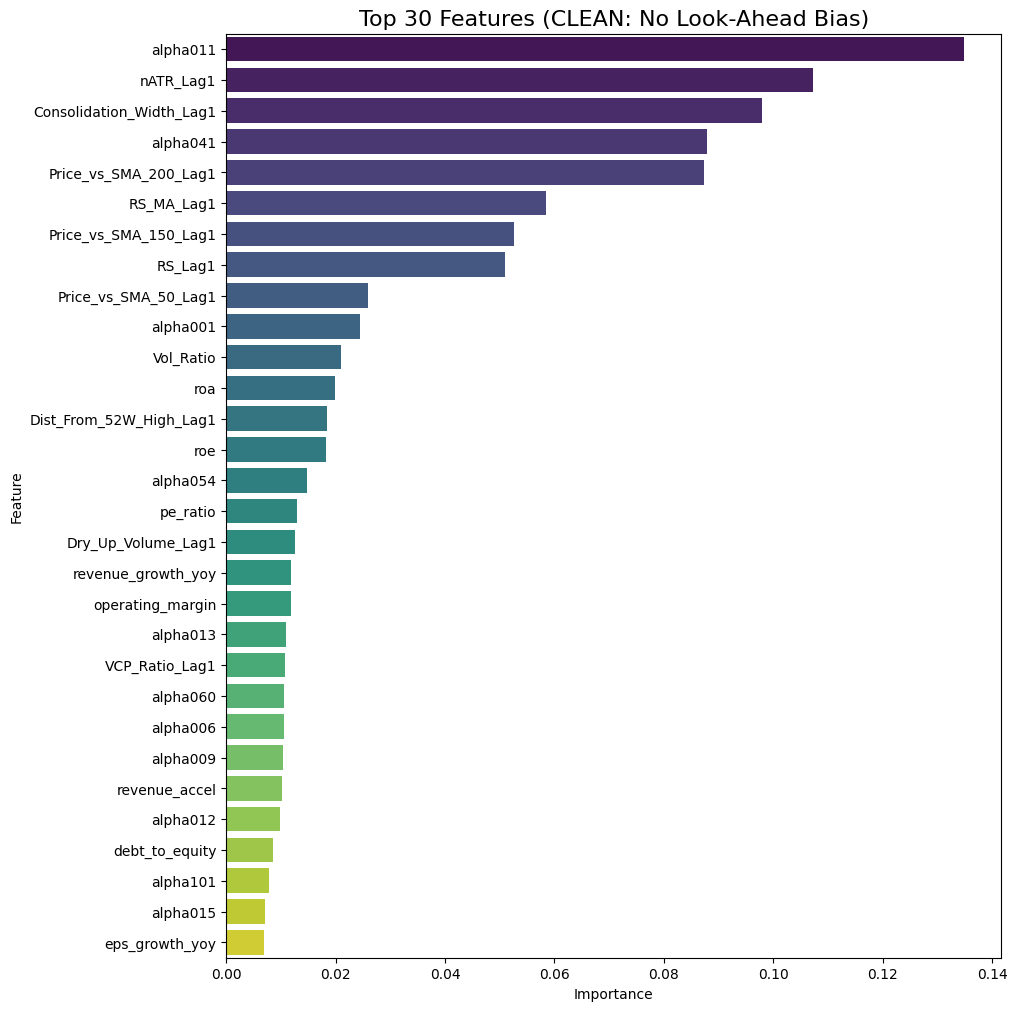

In [5]:
# ==========================================
# 1. DEFINE THE CLEAN FEATURE LIST
# ==========================================
# This list enforces the "Hybrid" Logic: 
# - Setup features are LAGGED (T-1)
# - Trigger features are CURRENT (Day T)
# ==========================================

features_to_analyze = [
    # --- THE SETUP (Lagged T-1) ---
    # These describe the "Quiet" base before the move.
    'nATR_Lag1',                # The most critical VCP metric
    'VCP_Ratio_Lag1',           # Volatility Contraction
    'Consolidation_Width_Lag1', # Base geometry
    'RS_Lag1',                  # Relative Strength Rank (Leader status)
    'RS_MA_Lag1',               # Trend of RS
    'Price_vs_SMA_50_Lag1',     # Trend extension
    'Price_vs_SMA_150_Lag1',
    'Price_vs_SMA_200_Lag1',
    'RSI_14_Lag1',              # Momentum context
    'Dry_Up_Volume_Lag1',       # Supply exhaustion
    'Dist_From_52W_High_Lag1',  # Proximity to high
    'Dist_From_52W_Low_Lag1',   # Proximity to low
    # 'High_52W_Lag1',            # Context
    # 'Low_52W_Lag1',

    # --- THE TRIGGER (Current Day T) ---
    # These describe the "Force" of the breakout today.
    'Vol_Ratio',                # The Explosion (Volume > 2x)
    # 'Breakout',               # Optional: If you have a binary flag
    
    # --- ALPHAS (Current Day T) ---
    # Fast signals describing immediate money flow.
    'alpha015', 'alpha041', 'alpha012', 'alpha101', 
    'alpha054', 'alpha001', 'alpha011', 'alpha013',
    'alpha060', 'alpha002', 'alpha004', 'alpha009', 'alpha006',

    # --- FUNDAMENTALS (Current/Recent) ---
    # These don't change daily, so "Current" is fine.
    'eps_growth_yoy', 'eps_accel',
    'revenue_growth_yoy', 'revenue_accel',
    'operating_margin', 'roe', 'roa',
    'pe_ratio', 'peg_adjusted',
    'debt_to_equity', 'current_ratio',
    'inventory_vs_sales_spread'
]

# ==========================================
# 2. CREATE CLEAN TRAINING DATA
# ==========================================

# Filter columns that actually exist
valid_features = [c for c in features_to_analyze if c in df.columns]

X = df[valid_features].copy()
y = df['label'].copy()

# --- THE FIX STARTS HERE ---

# 1. Replace Positive/Negative Infinity with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 2. Now Fill NaNs with 0 (or median if you prefer)
X = X.fillna(0)

# 3. Safety Clip: Cap values to avoid "Too Large for Float32" error
# (Some ratios can explode to 10^20, which breaks XGBoost/sklearn)
X = X.clip(lower=-1e8, upper=1e8)

# --- THE FIX ENDS HERE ---

print(f"✅ Data Cleaned: Infinity removed and values clipped.")
print(f"✅ Ready for Training!")
print(f"   Feature Count: {len(valid_features)}")

# ==========================================
# 3. RUN IMPORTANCE AGAIN
# ==========================================
from sklearn.ensemble import RandomForestClassifier

rf_clean = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clean.fit(X, y)

# Plotting code...
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance_clean = pd.DataFrame({
    'Feature': valid_features,
    'Importance': rf_clean.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data=importance_clean.head(30), x='Importance', y='Feature', palette='viridis')
plt.title("Top 30 Features (CLEAN: No Look-Ahead Bias)", fontsize=16)
plt.show()

In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & DATA CLEANING (Robust)
# ==========================================

# Sort by Date is MANDATORY for Walk-Forward
df_model = df.sort_values('date').reset_index(drop=True)

# --- THE FIX: CLEAN INFINITY GLOBALLY ---
# We must clean 'df_model' itself so X_train and X_test are both safe.

print("Cleaning data for XGBoost...")

# 1. Replace Infinity with NaN (XGBoost handles NaN, but chokes on Inf)
df_model[valid_features] = df_model[valid_features].replace([np.inf, -np.inf], np.nan)

# 2. Clip Extreme Values (Prevent float32 overflow)
# Some ratios like 'Revenue Growth' can be 10,000,000% if base is small.
df_model[valid_features] = df_model[valid_features].clip(lower=-1e9, upper=1e9)

# 3. (Optional) Fill NaN with 0 if you prefer, OR let XGBoost learn how to handle missing data.
# For SEPA, filling with 0 (Neutral) is usually safer than leaving it as NaN.
df_model[valid_features] = df_model[valid_features].fillna(0)

# ----------------------------------------

# Now define X and y from the CLEAN dataframe
X = df_model[valid_features]
y = df_model['label']
dates = df_model['date']

# Calculate Dynamic Scale Weight
pos_count = y.sum()
neg_count = len(y) - pos_count
scale_weight = neg_count / pos_count

print(f"Training on {len(df_model)} trades.")
print(f"Class Imbalance Weight: {scale_weight:.2f}")

# Hyperparameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 4,
    'learning_rate': 0.03,
    'n_estimators': 500,
    'colsample_bytree': 0.6,
    'subsample': 0.8,
    'scale_pos_weight': scale_weight,
    'random_state': 42,
    'n_jobs': 6,
    'early_stopping_rounds': 50  # Added to params as per previous fix
}

Cleaning data for XGBoost...
Training on 42795 trades.
Class Imbalance Weight: 9.15


In [7]:
# ==========================================
# 2. WALK-FORWARD VALIDATION LOOP (FIXED)
# ==========================================

# define folds
# We will split data by Years for clean boundaries
years = dates.dt.year.unique()
train_start_year = years[0] 
validation_years = years[2:] # Start testing after 2 years of data

results_log = []
all_predictions = [] # To store out-of-sample predictions

print(f"\nStarting Walk-Forward Validation ({len(validation_years)} Folds)...")

for test_year in validation_years:
    
    # A. Define Masks
    train_mask = dates.dt.year < test_year
    test_mask = dates.dt.year == test_year
    
    # B. Split Data
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    
    # Skip if empty
    if len(X_test) == 0: continue
        
    # C. Train Model (FIXED SYNTAX)
    # We pass early_stopping_rounds to the class constructor now
    model = xgb.XGBClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
        # Removed 'early_stopping_rounds' from here to fix the error
    )
    
    # D. Predict (Probabilities)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # ... (Rest of the loop remains the same) ...
    
    # E. Evaluate Fold
    auc = roc_auc_score(y_test, y_prob)
    
    results_df = pd.DataFrame({'target': y_test, 'prob': y_prob})
    results_df = results_df.sort_values('prob', ascending=False)
    top_10_pct = int(len(results_df) * 0.1)
    if top_10_pct > 0:
        top_picks = results_df.head(top_10_pct)
        precision_top_10 = top_picks['target'].mean()
    else:
        precision_top_10 = 0.0
    
    print(f"Year {test_year}: AUC = {auc:.4f} | Precision (Top 10%) = {precision_top_10:.2%}")
    
    results_log.append({
        'Year': test_year,
        'AUC': auc,
        'Precision_Top_10': precision_top_10,
        'Trade_Count': len(y_test)
    })
    
    fold_preds = df_model.loc[test_mask, ['date', 'ticker', 'label', 'return_pct']].copy()
    fold_preds['ml_score'] = y_prob
    all_predictions.append(fold_preds)

# ==========================================
# 3. GLOBAL PERFORMANCE VIEW
# ==========================================

final_results = pd.DataFrame(results_log)
print("\nOverall Performance:")
print(final_results.mean(numeric_only=True))

# Concatenate all out-of-sample predictions for final analysis
master_predictions = pd.concat(all_predictions)


Starting Walk-Forward Validation (21 Folds)...
Year 2005: AUC = 0.6606 | Precision (Top 10%) = 28.57%
Year 2006: AUC = 0.6613 | Precision (Top 10%) = 25.69%
Year 2007: AUC = 0.6546 | Precision (Top 10%) = 17.76%
Year 2008: AUC = 0.6378 | Precision (Top 10%) = 3.85%
Year 2009: AUC = 0.7011 | Precision (Top 10%) = 22.46%
Year 2010: AUC = 0.7076 | Precision (Top 10%) = 27.98%
Year 2011: AUC = 0.7391 | Precision (Top 10%) = 11.73%
Year 2012: AUC = 0.7074 | Precision (Top 10%) = 23.64%
Year 2013: AUC = 0.6576 | Precision (Top 10%) = 23.10%
Year 2014: AUC = 0.7147 | Precision (Top 10%) = 16.48%
Year 2015: AUC = 0.7741 | Precision (Top 10%) = 18.42%
Year 2016: AUC = 0.6457 | Precision (Top 10%) = 22.63%
Year 2017: AUC = 0.6709 | Precision (Top 10%) = 25.53%
Year 2018: AUC = 0.7227 | Precision (Top 10%) = 18.88%
Year 2019: AUC = 0.7371 | Precision (Top 10%) = 22.81%
Year 2020: AUC = 0.7380 | Precision (Top 10%) = 39.64%
Year 2021: AUC = 0.6724 | Precision (Top 10%) = 25.35%
Year 2022: AUC = 0

In [8]:
# recency weighting and hyperparameter tuning
import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# ==========================================
# 1. SETUP & RECENCY WEIGHTING
# ==========================================

# Use your existing 'df_model', 'X', 'y', 'dates' from the previous step
# Ensure they are sorted by date!

# Create Recency Weights (Exponential Decay)
# We want 2025 to have weight 1.0, and 2015 to have lower weight.
latest_date = dates.max()
days_diff = (latest_date - dates).dt.days

# Decay Rate: controls how fast history "fades"
# Lambda = 0.0005 means data from 5 years ago has ~40% weight of today
decay_rate = 0.0005 
sample_weights = np.exp(-decay_rate * days_diff)

# Normalize weights so average is 1.0 (keeps learning rate stable)
sample_weights = sample_weights / sample_weights.mean()

print(f"Weight Example - Today: {sample_weights.iloc[-1]:.2f}")
print(f"Weight Example - 5 Years Ago: {sample_weights.iloc[len(dates)//2]:.2f}")
print(f"Weight Example - 2005: {sample_weights.iloc[0]:.2f}")

# ==========================================
# 2. DEFINE TUNING OBJECTIVE (OPTUNA)
# ==========================================
# We will optimize specifically for the recent bear/bull cycle (2021-2024)
# to ensure the params work in the current volatility regime.

def objective(trial):
    
    # Suggest Hyperparameters
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'n_jobs': -1,
        'random_state': 42,
        'scale_pos_weight': scale_weight, # Keep your calculated class imbalance weight
        
        # Tuning ranges
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'gamma': trial.suggest_float('gamma', 0.1, 5.0), # Critical for noise reduction
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True), # L1 Reg
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True), # L2 Reg
    }
    
    # Validation Strategy for Tuning:
    # Train on 2005-2022, Validate on 2023-2024 (The most relevant "unseen" data)
    # This prevents overfitting to 2005 patterns that don't work anymore.
    
    split_year = 2023
    train_mask = dates.dt.year < split_year
    valid_mask = dates.dt.year >= split_year
    
    X_tr, y_tr = X[train_mask], y[train_mask]
    w_tr = sample_weights[train_mask] # Use weights for training!
    
    X_val, y_val = X[valid_mask], y[valid_mask]
    
    # Train
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_tr, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Evaluate
    preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds)
    
    return auc

# ==========================================
# 3. RUN OPTIMIZATION
# ==========================================
print("\n🔎 Starting Hyperparameter Tuning (20 Trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # Increase to 50+ for deeper search

print("\n✅ Best Parameters Found:")
best_params = study.best_params
print(best_params)

# ==========================================
# 4. FINAL TRAINING (REGIME OPTIMIZED)
# ==========================================
print("\n🚀 Training Final Model with Best Params & Recency Weights...")

# Add fixed params back
best_params['objective'] = 'binary:logistic'
best_params['eval_metric'] = 'auc'
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['scale_pos_weight'] = scale_weight

# Train on EVERYTHING (Up to yesterday) using Weights
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X, y, sample_weight=sample_weights, verbose=False)

# Save
final_model.save_model("sepa_xgboost_optimized.json")
print("✅ Optimized Model Saved.")

[I 2025-12-16 22:09:04,082] A new study created in memory with name: no-name-69b55f17-6c8e-423a-ac73-284754370847


Weight Example - Today: 3.60
Weight Example - 5 Years Ago: 0.63
Weight Example - 2005: 0.06

🔎 Starting Hyperparameter Tuning (20 Trials)...


[I 2025-12-16 22:09:05,724] Trial 0 finished with value: 0.6809545481263269 and parameters: {'max_depth': 5, 'learning_rate': 0.0277515171539107, 'n_estimators': 374, 'subsample': 0.6683776889685318, 'colsample_bytree': 0.8711081950318991, 'gamma': 2.5081863282124126, 'min_child_weight': 4, 'reg_alpha': 0.014848719529443576, 'reg_lambda': 9.483751737321363}. Best is trial 0 with value: 0.6809545481263269.
[I 2025-12-16 22:09:07,021] Trial 1 finished with value: 0.6720399923241291 and parameters: {'max_depth': 4, 'learning_rate': 0.07221431829635074, 'n_estimators': 396, 'subsample': 0.7505062936529081, 'colsample_bytree': 0.7117952944182605, 'gamma': 2.818976955399932, 'min_child_weight': 3, 'reg_alpha': 0.048911444446826685, 'reg_lambda': 0.34346994181670887}. Best is trial 0 with value: 0.6809545481263269.
[I 2025-12-16 22:09:09,738] Trial 2 finished with value: 0.6807376918103298 and parameters: {'max_depth': 5, 'learning_rate': 0.023402147762928177, 'n_estimators': 718, 'subsample'


✅ Best Parameters Found:
{'max_depth': 3, 'learning_rate': 0.058673232752901414, 'n_estimators': 478, 'subsample': 0.8516925513918988, 'colsample_bytree': 0.7388502249412228, 'gamma': 0.14481422571081914, 'min_child_weight': 2, 'reg_alpha': 1.587557454473949, 'reg_lambda': 1.9260341079382859}

🚀 Training Final Model with Best Params & Recency Weights...
✅ Optimized Model Saved.


In [18]:
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import joblib
from datetime import datetime, timedelta

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================

# Your Best Parameters from Optuna
best_params = {
    'max_depth': 4,
    'learning_rate': 0.022227020073763384,
    'n_estimators': 521,
    'subsample': 0.8915535392930269,
    'colsample_bytree': 0.7366487150488391,
    'gamma': 1.430375132582225,
    'min_child_weight': 2,
    'reg_alpha': 0.07798221765915406,
    'reg_lambda': 0.7066586609170594,
    # Fixed Params
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
    'scale_pos_weight': 9.15  # Use your calculated Class Imbalance Weight
}

# ==========================================
# 2. DEFINE TRAINING SCOPE (Maturation Buffer)
# ==========================================

# Sort by Date is MANDATORY
df_model = df_model.sort_values('date').reset_index(drop=True)
dates = df_model['date']

# Calculate Cutoff: Today - 3 Months
# We exclude the most recent 3 months because those trades are "unresolved"
last_available_date = dates.max()
cutoff_date = last_available_date - timedelta(days=90)

print(f"📅 Data Range: {dates.min().date()} to {cutoff_date.date()}")
print(f"   (Dropped data after {cutoff_date.date()} to ensure trade outcome maturity)")

# Create the Final Mask
production_mask = dates <= cutoff_date

# Apply Mask
X_prod = X[production_mask].copy()
y_prod = y[production_mask].copy()
dates_prod = dates[production_mask].copy()

print(f"📊 Final Training Count: {len(X_prod)} trades")

# ==========================================
# 3. APPLY RECENCY WEIGHTING
# ==========================================

# Recalculate weights specifically for this filtered dataset
# We want the 'cutoff_date' (the most recent valid data) to have Weight = 1.0
days_diff = (cutoff_date - dates_prod).dt.days

# Decay Rate: 0.0005 (Standard for ~5-7 year half-life relevance)
decay_rate = 0.0005
sample_weights = np.exp(-decay_rate * days_diff)

# Normalize so average weight is 1.0 (keeps learning rate stable)
sample_weights = sample_weights / sample_weights.mean()

print(f"⚖️  Weight Stats:")
print(f"   Recent ({dates_prod.max().date()}): {sample_weights.iloc[-1]:.4f}")
print(f"   Oldest ({dates_prod.min().date()}): {sample_weights.iloc[0]:.4f}")

# ==========================================
# 4. TRAIN MASTER MODEL
# ==========================================
print("\n🚀 Training Production Model on Full History...")

model_final = xgb.XGBClassifier(**best_params)

# Train on 100% of Production Data using Weights
# No eval_set or early_stopping because we want to use ALL data
model_final.fit(
    X_prod, 
    y_prod, 
    sample_weight=sample_weights,
    verbose=False
)

# ==============================================================================
# 5. SAVE ARTIFACTS (SIDECAR METHOD)
# ==============================================================================
import json
import os
from datetime import datetime

# Define paths
# 1. The Model File (Pure XGBoost JSON)
model_path = "models/production_model.json"

# 2. The Metadata File (Sidecar)
#    MLScorer looks for exactly: model filename + ".metadata"
metadata_path = "models/production_model_metadata.json"

# SAVE MODEL: Pure XGBoost format
# Use the correct variable name 'model_final' from Step 4
model_final.save_model(model_path)
print(f"✅ Model saved to: {model_path}")

# SAVE METADATA: Custom JSON Sidecar
metadata = {
    "model_type": "xgboost",
    "version": "optimized_v1",
    "date": datetime.now().strftime("%Y-%m-%d"),
    "feature_names": list(X_prod.columns),  # Use X_prod to be safe
    "params": best_params
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Metadata saved to: {metadata_path}")
print(f"   (MLScorer will automatically detect this sidecar file)")

📅 Data Range: 2003-04-02 to 2025-09-06
   (Dropped data after 2025-09-06 to ensure trade outcome maturity)
📊 Final Training Count: 41786 trades
⚖️  Weight Stats:
   Recent (2025-09-05): 3.6676
   Oldest (2003-04-02): 0.0610

🚀 Training Production Model on Full History...
✅ Model saved to: models/production_model.json
✅ Metadata saved to: models/production_model_metadata.json
   (MLScorer will automatically detect this sidecar file)


In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import os
from datetime import datetime, timedelta
from pathlib import Path

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================

# ------------------------------------------------------------
# YOUR OPTIMIZED PARAMS (From Optuna)
# ------------------------------------------------------------
best_params = {
    'max_depth': 4,
    'learning_rate': 0.022227020073763384,
    'n_estimators': 521,
    'subsample': 0.8915535392930269,
    'colsample_bytree': 0.7366487150488391,
    'gamma': 1.430375132582225,
    'min_child_weight': 2,
    'reg_alpha': 0.07798221765915406,
    'reg_lambda': 0.7066586609170594,
    # Fixed Params
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
    'scale_pos_weight': 9.15
}

# ==========================================
# 2. PREPARE PRODUCTION DATA
# ==========================================
print("🔄 Preparing Production Data...")

# Ensure sorted
df_model = df_model.sort_values('date').reset_index(drop=True)
dates = df_model['date']

# MATURATION BUFFER: Drop last 90 days
cutoff_date = dates.max() - timedelta(days=90)
production_mask = dates <= cutoff_date

X_prod = X[production_mask].copy()
y_prod = y[production_mask].copy()
dates_prod = dates[production_mask].copy()

print(f"   Training Rows: {len(X_prod):,}")

# ==========================================
# 3. RECENCY WEIGHTING
# ==========================================
days_diff = (cutoff_date - dates_prod).dt.days
decay_rate = 0.0005
sample_weights = np.exp(-decay_rate * days_diff)
sample_weights = sample_weights / sample_weights.mean()

# ==========================================
# 4. TRAIN MODEL
# ==========================================
print("\n🚀 Training Production Model...")

model_final = xgb.XGBClassifier(**best_params)
model_final.fit(
    X_prod, 
    y_prod, 
    sample_weight=sample_weights,
    verbose=False
)
print("✅ Training Complete.")

# ==========================================
# 5. SAVE ARTIFACTS (STRICT NAMING CONVENTION)
# ==========================================
# Logic: Scorer replaces 'model' -> 'model_metadata'
# So we save:
#   Model:    model_prod.json
#   Metadata: model_metadata_prod.json

output_dir = Path("models")
output_dir.mkdir(exist_ok=True)

# Define Filenames
model_filename = "model_prod.json"
metadata_filename = "model_metadata_prod.json"

model_path = output_dir / model_filename
metadata_path = output_dir / metadata_filename

print(f"\n💾 Saving Artifacts to: {output_dir.resolve()}")

# A. Save Pure XGBoost Model
model_final.save_model(model_path)
print(f"   [1/2] Model saved:    {model_filename}")

# B. Save Metadata
metadata = {
    "model_type": "xgboost",
    "version": "prod_v1",
    "training_date": datetime.now().strftime("%Y-%m-%d"),
    "feature_names": list(X_prod.columns),  # <--- CRITICAL
    "params": best_params
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
    
print(f"   [2/2] Metadata saved: {metadata_filename}")

print("\n✅ DONE! Initialize scorer with:")
print(f'   scorer = MLScorer(model_path="models/{model_filename}")')

🔄 Preparing Production Data...
   Training Rows: 41,786

🚀 Training Production Model...
✅ Training Complete.

💾 Saving Artifacts to: /Users/ceolwaerc/Desktop/Projects/mm-strat/models
   [1/2] Model saved:    model_prod.json
   [2/2] Metadata saved: model_metadata_prod.json

✅ DONE! Initialize scorer with:
   scorer = MLScorer(model_path="models/model_prod.json")


In [23]:
import importlib
import src.ml_scorer

# 1. Force reload the module from disk
importlib.reload(src.ml_scorer)

# 2. Re-import the class from the reloaded module
from src.ml_scorer import MLScorer

print("✅ Module reloaded. You are now using the updated code.")

# 3. Now initialize it
# (It will auto-discover the metadata file now)
ml_scorer = MLScorer(model_path=model_path, log_predictions=False)

INFO:src.ml_scorer:Model loaded: models/model_prod.json
INFO:src.ml_scorer:Metadata loaded: 37 features expected
INFO:src.ml_scorer:MLScorer initialized with model: model_prod.json
INFO:src.ml_scorer:  Features required: 37
INFO:src.ml_scorer:  Model version: 2025-12-16
INFO:src.ml_scorer:  Prediction logging: OFF


✅ Module reloaded. You are now using the updated code.


# Scanner

In [5]:
# ============================================================================
# CELL 14: Define Scanner Scope
# ============================================================================

print("🔍 DAILY SCANNER")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Run the daily scanner to find buy/sell signals

# Scan Mode
# Purpose: Choose between single-day or date-range scanning
# Options: 'single_day' (one specific date), 'date_range' (scan multiple days)
scan_mode = 'date_range'  # Example: 'single_day', 'date_range'

# Single Day Scan Date
# Purpose: Which date to scan (only used if scan_mode='single_day')
scan_date_single = datetime.now().strftime('%Y-%m-%d')  # Example: datetime.now() (today)

# Date Range (only used if scan_mode='date_range')
# Purpose: Define start and end dates for multi-day scanning
start_date_range = '2025-11-17'#(datetime.now() - timedelta(days=30)).strftime('%Y-%m-%d')  # Example: 30 days ago
end_date_range = '2025-11-28'#datetime.now().strftime('%Y-%m-%d')  # Example: today

# ML Scoring
# Purpose: Enable ML model to rank and filter signals
use_ml_scanner = False  # Example: False (rule-based only), True (use ML scoring)

# ML Model Path (only used if use_ml_scanner=True)
# Purpose: Path to production model file
model_path_scanner = 'models/sepa_xgboost_master.json'  # Example: 'models/model_production.json'

# Output Options
# Purpose: Export results to CSV file
csv_output_scanner = True  # Example: False (display only), True (save to CSV)

# Debug Mode
# Purpose: Show detailed metrics for debugging
debug_mode_scanner = True  # Example: False (summary only), True (detailed metrics)

# Ticker Filter (optional)
# Purpose: Scan only specific tickers instead of full universe
# Leave empty to scan all tickers
use_loaded_tickers = True
scanner_tickers_input = 'ROST,AAPL,MSFT,GOOGL'  # Example: '', 'AAPL,MSFT,TSLA'

# === EXECUTION ===
try:
    # Parse tickers
    scanner_tickers = None
    if scanner_tickers_input.strip():
        scanner_tickers = [t.strip().upper() for t in scanner_tickers_input.split(',') if t.strip()]

    # Import scanner
    from optimized_scanner import run_optimized_scanner

    if scan_mode == 'single_day':
        print(f"\n🔍 Running single-day scan for {scan_date_single}...\n")

        run_optimized_scanner(
            scan_date=scan_date_single,
            csv_output=csv_output_scanner,
            use_ml=use_ml_scanner,
            model_path=model_path_scanner if use_ml_scanner else None,
            tickers=scanner_tickers,
            debug=debug_mode_scanner
        )
    else:
        print(f"\n🔍 Running date-range scan from {start_date_range} to {end_date_range}...\n")
        print("⚠️  Date range mode uses 2D vectorized scanning (faster)\n")

        import sys
        from datetime import datetime, timedelta
        import pandas as pd
        import time

        # Simulate command-line args
        class Args:
            def __init__(self):
                self.date_range = [start_date_range, end_date_range]
                self.use_ml = use_ml_scanner
                self.model_path = model_path_scanner if use_ml_scanner else None

        args = Args()

        from src.data_engine import DataRepository
        from src.features import FeatureEngineer
        from src.vectorized_screening import VectorizedSEPAScreener

        start_date = datetime.strptime(args.date_range[0], '%Y-%m-%d')
        end_date = datetime.strptime(args.date_range[1], '%Y-%m-%d')

        print("[PRE-SCAN] Updating cache...")
        data_repo = DataRepository()
        if use_loaded_tickers:
            tickers = scanner_tickers
        else:
            tickers = data_repo.update_universe()

        tickers.append(config.BENCHMARK_TICKER)
        
        # 1. OPTIMIZATION: Only load last 2 years of data
        # We only need enough history for SMA200 and 52-week Highs
        min_date_history = (start_date - timedelta(days=730)).strftime('%Y-%m-%d')
        
        # Only update cache for active tickers to save time
        data_repo.update_cache(tickers, force=False, source='fmp')

        print(f"[PRE-SCAN] Loading price data (from {min_date_history})...")
        # 2. OPTIMIZATION: Pass min_date to avoid loading 20+ years of history
        all_ticker_data = data_repo.get_batch_data(
            tickers, 
            min_date=min_date_history, 
            check_min_date=False
        )
        print(f"Loaded {len(all_ticker_data)} tickers.")

        print("\n[Step 1/4] Computing lightweight features...")
        benchmark_data = data_repo.get_benchmark_data(check_min_date=False, min_date=min_date_history)
        feature_engine = FeatureEngineer(benchmark_data=benchmark_data)
        
        # This calculates SMAs, RSI, etc. on the trimmed dataset
        enriched_data = feature_engine.process_universe_batch(all_ticker_data)

        print("[Step 2/4] Building 2D matrix...")
        # Lookback needs to cover the scan window + enough prior days for signals to form
        lookback_days = 365 
        data_start_date = start_date - timedelta(days=lookback_days)
        
        df_matrix = VectorizedSEPAScreener.build_2d_matrix(
            enriched_data,
            start_date=pd.Timestamp(data_start_date),
            end_date=pd.Timestamp(end_date)
        )

        print("[Step 3/4] Computing SEPA status...")
        df_matrix = VectorizedSEPAScreener.add_sepa_status_column(df_matrix)

        print("[Step 4/4] Finding signal transitions...")
        buy_signals, sell_signals = VectorizedSEPAScreener.find_signal_transitions(
            df_matrix,
            date_range_start=pd.Timestamp(start_date),
            date_range_end=pd.Timestamp(end_date)
        )

        print(f"\n✅ Date range scan complete!")
        print(f"   Buy signals: {len(buy_signals)}")
        print(f"   Sell signals: {len(sell_signals)}")
        
        # OPTIONAL: Apply ML Scoring on the signals here
        if use_ml_scanner and len(buy_signals) > 0:
             print(f"\n[ML] Scoring {len(buy_signals)} buy signals...")
             # (Add your ML scoring logic here if needed for date_range mode)

except Exception as e:
    print(f"❌ Error running scanner: {e}")
    import traceback
    traceback.print_exc()

INFO:src.data_engine:Fetching latest trading day...
INFO:src.data_engine:Latest trading day is: 2025-12-15 00:00:00
INFO:src.data_engine:Checking 5 files (Parallel Metadata Scan)...


🔍 DAILY SCANNER

🔍 Running date-range scan from 2025-11-17 to 2025-11-28...

⚠️  Date range mode uses 2D vectorized scanning (faster)

[PRE-SCAN] Updating cache...


Scanning cache: 100%|██████████| 5/5 [00:00<00:00, 90.40file/s]
INFO:src.data_engine:✅ All tickers up to date.


[PRE-SCAN] Loading price data (from 2023-11-18)...


INFO:src.features:FeatureEngineer initialized in dual-stage mode


Loaded 5 tickers.

[Step 1/4] Computing lightweight features...


Computing Features: 100%|██████████| 5/5 [00:00<00:00, 51.40ticker/s]
INFO:src.features:Batch processed 5/5 tickers successfully
INFO:src.vectorized_screening:Built 2D matrix: 1290 rows (5 tickers × 377 dates)
INFO:src.vectorized_screening:SEPA status computed for 1290 rows
INFO:src.vectorized_screening:Found 1 buy signals and 1 sell signals in range 2025-11-17 to 2025-11-28


[Step 2/4] Building 2D matrix...
[Step 3/4] Computing SEPA status...
[Step 4/4] Finding signal transitions...

✅ Date range scan complete!
   Buy signals: 1
   Sell signals: 1


In [6]:
buy_signals.head()

,Open,High,Low,Close,Volume,SMA_50,Price_vs_SMA_50,SMA_150,Price_vs_SMA_150,SMA_200,...,High_52W_Lag1,Low_52W_Lag1,RSI_14_Lag1,Dist_From_52W_High_Lag1,ticker,date,SEPA_Status,SEPA_prev,is_buy,is_sell
1029,668.63,676.21,664.48,675.02,81077100,669.6058,0.808565,632.271933,6.761026,615.2831,...,687.39,496.48,45.65014,-2.714616,SPY,2025-11-25,True,False,True,False


In [13]:
base_dir = Path('data/scanner_output')
csv_filename = f"scan_results_{start_date_range}_{end_date_range}.csv"
csv_path = base_dir / csv_filename
buy_signals.to_csv(csv_path, index=False)

In [10]:
try:
    print(f"\n📋 Loading buy list...\n")

    if buy_list_df.empty:
        print("No active buy signals found.")
    else:
        # Calculate price changes
        if 'signal_price' in buy_list_df.columns and 'current_price' in buy_list_df.columns:
            buy_list_df['price_change_$'] = buy_list_df['current_price'] - buy_list_df['signal_price']
            buy_list_df['price_change_%'] = ((buy_list_df['current_price'] - buy_list_df['signal_price']) / buy_list_df['signal_price'] * 100)

        # Sort
        if sort_by_buylist in buy_list_df.columns:
            buy_list_df = buy_list_df.sort_values(sort_by_buylist)

        # Display summary
        print(f"✅ Buy List loaded ({len(buy_list_df)} signals)\n")
        print(f"📊 Summary Statistics:")

        if 'signal_date' in buy_list_df.columns:
            buy_list_df['days_on_list'] = (pd.Timestamp(as_of_date_buylist) - pd.to_datetime(buy_list_df['signal_date'])).dt.days
            print(f"   Avg days on list: {buy_list_df['days_on_list'].mean():.1f}")
            print(f"   Newest signal: {buy_list_df['signal_date'].max()}")
            print(f"   Oldest signal: {buy_list_df['signal_date'].min()}")

        if 'price_change_%' in buy_list_df.columns:
            print(f"\n💰 Performance:")
            print(f"   Avg return: {buy_list_df['price_change_%'].mean():.2f}%")
            print(f"   Best performer: {buy_list_df.loc[buy_list_df['price_change_%'].idxmax(), 'ticker']} (+{buy_list_df['price_change_%'].max():.2f}%)")
            print(f"   Worst performer: {buy_list_df.loc[buy_list_df['price_change_%'].idxmin(), 'ticker']} ({buy_list_df['price_change_%'].min():.2f}%)")

        # Display dataframe
        print(f"\n📋 BUY LIST:\n")
        display_cols = ['ticker', 'signal_date', 'signal_price', 'current_price', 'price_change_%',
                       'rs', 'volume_ratio', 'ml_probability', 'ml_rank']
        available_cols = [col for col in display_cols if col in buy_list_df.columns]
        display(buy_list_df[available_cols].head(50))

        # Export if requested
        if export_csv_buylist:
            output_path = Path('data/scanner_output') / f'buy_list_{as_of_date_buylist}.csv'
            output_path.parent.mkdir(parents=True, exist_ok=True)
            buy_list_df.to_csv(output_path, index=False)
            print(f"\n💾 Exported to: {output_path}")

except Exception as e:
    print(f"❌ Error loading buy list: {e}")
    import traceback
    traceback.print_exc()


📋 Loading buy list...

✅ Buy List loaded (685 signals)

📊 Summary Statistics:

📋 BUY LIST:



,ticker
77973,A
367044,AA
205907,AAMI
395230,AAP
73488,ABBV
73496,ABBV
544041,ACA
280859,ACAD
257546,ACLS
214244,ACMR


# [Placeholder] Deprecated code

In [5]:
# ============================================================================
# CELL 9: Data Preparation / Feature Engineering Framework
# ============================================================================

print("🔧 FEATURE ENGINEERING FRAMEWORK")
print("=" * 80)
print("\nThis cell provides a framework for custom feature engineering.")
print("Modify the code below to add your custom logic.\n")

# === CONFIGURATION ===
training_dataset_path_fe = 'data/ml/training_dataset_final.parquet'
output_path_fe = 'data/ml/training_dataset_cleaned.parquet'

# === LOAD DATASET ===
print("[1/5] Loading training dataset...")
df_fe = pd.read_parquet(training_dataset_path_fe)
print(f"   Loaded {len(df_fe):,} rows, {len(df_fe.columns)} columns\n")

# === HANDLE MISSING VALUES ===
print("[2/5] Handling missing values...")
print(f"   Missing values before: {df_fe.isnull().sum().sum():,} ({df_fe.isnull().sum().sum()/df_fe.size*100:.2f}%)")

# TODO: Add your custom missing value handling here
# Example:
# df_fe['feature_name'] = df_fe['feature_name'].fillna(df_fe['feature_name'].median())

print(f"   Missing values after: {df_fe.isnull().sum().sum():,} ({df_fe.isnull().sum().sum()/df_fe.size*100:.2f}%)\n")

# === FEATURE SCALING / NORMALIZATION ===
print("[3/5] Feature scaling / normalization...")

# TODO: Add your custom scaling logic here
# Example:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# df_fe[numeric_cols] = scaler.fit_transform(df_fe[numeric_cols])

print("   Scaling complete\n")

# === FEATURE CREATION ===
print("[4/5] Creating custom features...")

# TODO: Add your custom feature creation here
# Example:
# df_fe['custom_feature'] = df_fe['feature1'] / df_fe['feature2']

print(f"   Total features: {len(df_fe.columns)}\n")

# === SAVE CLEANED DATASET ===
print("[5/5] Saving cleaned dataset...")
output_path = Path(output_path_fe)
output_path.parent.mkdir(parents=True, exist_ok=True)
df_fe.to_parquet(output_path, index=False)
print(f"   ✅ Saved to: {output_path}")
print(f"   Size: {output_path.stat().st_size / (1024*1024):.2f} MB\n")

print("✅ Feature engineering complete!")

🔧 FEATURE ENGINEERING FRAMEWORK

This cell provides a framework for custom feature engineering.
Modify the code below to add your custom logic.

[1/5] Loading training dataset...
   Loaded 42,795 rows, 230 columns

[2/5] Handling missing values...
   Missing values before: 2,157,684 (21.92%)
   Missing values after: 2,157,684 (21.92%)

[3/5] Feature scaling / normalization...
   Scaling complete

[4/5] Creating custom features...
   Total features: 230

[5/5] Saving cleaned dataset...
   ✅ Saved to: data/ml/training_dataset_cleaned.parquet
   Size: 40.69 MB

✅ Feature engineering complete!


## Cell 10: Define Fold and Training Parameters

Configure temporal splitting and feature selection parameters.

In [ ]:
# ============================================================================
# CELL 10: Define Fold and Training Parameters
# ============================================================================

print("⚙️ TRAINING CONFIGURATION")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Configure temporal cross-validation and feature selection for ML training

# Dataset Path
# Purpose: Location of the merged training dataset
dataset_path_train = 'data/ml/training_dataset_final.parquet'  # Example: 'data/ml/training_dataset_final.parquet'

# Temporal Splitting
# Purpose: Days to exclude between train and test to prevent look-ahead bias
# Larger values = more conservative but less training data
purge_gap_days = 60  # Example: 60 (recommended 30-120 days)

# Feature Selection
# Purpose: Remove highly correlated features to reduce overfitting
correlation_threshold = 0.95  # Example: 0.95 (remove features with >95% correlation)

# Top N Features
# Purpose: Keep only the N most important features (0 = keep all after correlation filtering)
top_n_features = 0  # Example: 0 (keep all), 50 (keep top 50 features)

# Evaluation Metric
# Purpose: Precision@k measures accuracy in the top k% of predictions
# This aligns with real trading (we only trade the highest-confidence signals)
precision_k_pct = 0.2  # Example: 0.2 (top 20% of predictions)

# Hyperparameter Optimization
# Purpose: Use Optuna to find optimal XGBoost parameters (slow but improves accuracy)
optimize_hyperparameters = False  # Example: False (use defaults), True (run optimization)

# Optuna Trials
# Purpose: How many hyperparameter combinations to try (only used if optimize_hyperparameters=True)
n_optuna_trials = 50  # Example: 50 (10-100 recommended)

# === EXECUTION ===
train_config = {}  # Global variable to store configuration

try:
    print(f"\n🔧 Preparing training configuration...\n")

    # Import preparation modules
    from src.model_preparation import prepare_training_data

    # Prepare data
    top_n = top_n_features if top_n_features > 0 else None

    prep_result = prepare_training_data(
        dataset_path=dataset_path_train,
        purge_gap_days=purge_gap_days,
        correlation_threshold=correlation_threshold,
        keep_top_n=top_n
    )

    # Store configuration
    train_config = {
        'df': prep_result['df'],
        'folds': prep_result['folds'],
        'splitter': prep_result['splitter'],
        'selector': prep_result['selector'],
        'optimize': optimize_hyperparameters,
        'n_trials': n_optuna_trials,
        'precision_k': precision_k_pct
    }

    # Display summary
    print(f"✅ Training preparation complete!\n")
    print(f"📊 Configuration:")
    print(f"   Dataset: {len(train_config['df']):,} rows")
    print(f"   Temporal Folds: {len(train_config['folds'])}")
    print(f"   Selected Features: {len(train_config['selector'].selected_features)}")
    print(f"   Dropped Features: {sum(len(v) for v in train_config['selector'].dropped_features.values())}")
    print(f"   Purge Gap: {purge_gap_days} days")
    print(f"   Optimize Hyperparameters: {optimize_hyperparameters}")
    if optimize_hyperparameters:
        print(f"   Optuna Trials: {n_optuna_trials}")
    print(f"   Precision@k: {int(precision_k_pct*100)}%")

    # Display fold structure
    print(f"\n📅 Fold Structure:")
    for fold in train_config['folds']:
        fold_type = "PRODUCTION" if fold.get('is_production', False) else "Validation"
        print(f"   Fold {fold['fold_id']} ({fold_type}):")
        print(f"     Train: {fold['train_start']} to {fold['train_end']} ({fold['train_size']:,} rows)")
        if not fold.get('is_production', False):
            print(f"     Test:  {fold['test_start']} to {fold['test_end']} ({fold['test_size']:,} rows)")

except Exception as e:
    print(f"❌ Error preparing training: {e}")
    import traceback
    traceback.print_exc()

## Cell 11: Train Model

Train XGBoost models for each temporal fold.

In [ ]:
# ============================================================================
# CELL 11: Train Model
# ============================================================================

print("🚀 MODEL TRAINING")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Train XGBoost models for each temporal fold

# Model Output Directory
# Purpose: Where to save trained model files
model_output_dir = 'models'  # Example: 'models'

# Evaluation Output Directory
# Purpose: Where to save evaluation plots and metrics
eval_output_dir = 'evaluation'  # Example: 'evaluation'

# GPU Acceleration
# Purpose: Use GPU for faster training (requires XGBoost with CUDA support)
use_gpu = False  # Example: False (CPU), True (GPU if available)

# === EXECUTION ===
trained_models = []  # Global variable to store trained models

try:
    # Check if training config exists
    if not train_config:
        print("❌ No training configuration! Please run Cell 10 first.")
        raise ValueError("Training configuration not found")

    print(f"\n🚀 Training {len(train_config['folds'])} fold(s)...\n")

    # Import trainer
    from src.train_model import SEPAModelTrainer

    # Create output directories
    Path(model_output_dir).mkdir(parents=True, exist_ok=True)
    Path(eval_output_dir).mkdir(parents=True, exist_ok=True)

    trained_models = []

    for fold_idx, fold in enumerate(train_config['folds']):
        fold_type = "PRODUCTION" if fold.get('is_production', False) else "Validation"
        print(f"\n{'='*80}")
        print(f"TRAINING FOLD {fold['fold_id']} ({fold_type})")
        print(f"{'='*80}\n")

        # Get train/test data
        X_train, X_test, y_train, y_test = train_config['splitter'].get_fold_data(
            train_config['df'],
            fold_idx=fold_idx,
            feature_columns=train_config['selector'].selected_features
        )

        # Apply feature selection
        X_train = train_config['selector'].transform(X_train)
        X_test = train_config['selector'].transform(X_test)

        # Split train/val for validation folds
        if fold.get('is_production', False):
            X_train_split = X_train
            y_train_split = y_train
            X_val_split = None
            y_val_split = None
            print(f"Production fold: Using ALL training data ({len(X_train_split)} rows)\n")
        else:
            train_size = int(len(X_train) * 0.8)
            X_train_split = X_train.iloc[:train_size]
            y_train_split = y_train.iloc[:train_size]
            X_val_split = X_train.iloc[train_size:]
            y_val_split = y_train.iloc[train_size:]
            print(f"Train: {len(X_train_split)}, Val: {len(X_val_split)}, Test: {len(X_test)} rows\n")

        # Initialize trainer
        trainer = SEPAModelTrainer(precision_k_pct=train_config['precision_k'])

        # Optimize hyperparameters (only on first fold)
        if train_config['optimize'] and fold_idx == 0:
            print(f"Optimizing hyperparameters ({train_config['n_trials']} trials)...")
            best_params = trainer.optimize_hyperparameters(
                X_train_split,
                y_train_split,
                X_val_split,
                y_val_split,
                n_trials=train_config['n_trials']
            )
            print(f"Best parameters found!\n")
        elif fold_idx > 0 and train_config['optimize']:
            print("Reusing hyperparameters from Fold 1\n")
            trainer.best_params = trained_models[0].best_params

        # Train model
        print("Training final model...")
        model = trainer.train_with_best_params(
            X_train_split,
            y_train_split,
            X_val_split,
            y_val_split
        )

        # Save model
        trainer.save_model(model_output_dir, fold_id=fold['fold_id'])
        trained_models.append(trainer)

        print(f"\n✅ Fold {fold['fold_id']} training complete!")

    print(f"\n{'='*80}")
    print(f"✅ ALL MODELS TRAINED SUCCESSFULLY!")
    print(f"{'='*80}")
    print(f"\n📁 Models saved to: {Path(model_output_dir).resolve()}")
    print(f"   Total models: {len(trained_models)}")

except Exception as e:
    print(f"❌ Error training models: {e}")
    import traceback
    traceback.print_exc()

## Cell 12: Review Results and Select Best Model

Compare fold performance and select the best model for production.

In [ ]:
# ============================================================================
# CELL 12: Review Results and Select Best Model
# ============================================================================

print("📊 MODEL EVALUATION & SELECTION")
print("=" * 80)
print("\nThis cell evaluates all trained folds and helps you select the best model.\n")

# Check if models are trained
if not trained_models:
    print("❌ No trained models found! Please run Cell 11 first.")
else:
    # Import evaluator
    from src.evaluate_model import ModelEvaluator
    
    eval_dir = eval_output_dir.value
    evaluator = ModelEvaluator(output_dir=eval_dir)
    
    # Evaluate each fold (skip production folds)
    all_fold_results = []
    
    for fold_idx, fold in enumerate(train_config['folds']):
        if fold.get('is_production', False):
            print(f"Skipping Fold {fold['fold_id']} (PRODUCTION - no test data)\n")
            continue
        
        print(f"Evaluating Fold {fold['fold_id']}...")
        
        # Get test data
        X_train, X_test, y_train, y_test = train_config['splitter'].get_fold_data(
            train_config['df'],
            fold_idx=fold_idx,
            feature_columns=train_config['selector'].selected_features
        )
        
        X_test = train_config['selector'].transform(X_test)
        test_indices = fold['test_indices']
        df_test = train_config['df'].loc[test_indices]
        
        # Get trained model
        model = trained_models[fold_idx].model
        
        # Evaluate
        fold_results = evaluator.evaluate_fold(
            model=model,
            X_test=X_test,
            y_test=y_test,
            df_test=df_test,
            fold_id=fold['fold_id'],
            k_values=[0.1, 0.2, 0.3]
        )
        
        all_fold_results.append(fold_results)
    
    # Generate comprehensive report
    evaluator.generate_report(
        all_fold_results,
        output_path=f'{eval_dir}/evaluation_report.json'
    )
    
    # Create comparison table
    comparison_data = []
    for result in all_fold_results:
        comparison_data.append({
            'Fold': result['fold_id'],
            'Precision@10%': result['metrics']['precision_at_k'].get(0.1, 0),
            'Precision@20%': result['metrics']['precision_at_k'].get(0.2, 0),
            'Precision@30%': result['metrics']['precision_at_k'].get(0.3, 0),
            'Win Rate': result['backtest']['win_rate'],
            'Avg Return': result['backtest']['avg_return'],
            'AUC-ROC': result['metrics']['auc_roc']
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print(f"\n✅ Evaluation complete!\n")
    print("📊 FOLD COMPARISON:")
    print("=" * 80)
    display(comparison_df)
    
    # Visualizations
    print(f"\n📈 Visualizations saved to: {eval_dir}/")
    print(f"   - ROC curves: roc_curve_fold_*.png")
    print(f"   - Feature importance: feature_importance_fold_*.png")
    print(f"   - Full report: evaluation_report.json")
    
    # Selection helper
    print(f"\n🎯 MODEL SELECTION HELPER:")
    print("=" * 80)
    
    best_by_precision = comparison_df.loc[comparison_df['Precision@20%'].idxmax()]
    best_by_return = comparison_df.loc[comparison_df['Avg Return'].idxmax()]
    
    print(f"\n   Best by Precision@20%: Fold {best_by_precision['Fold']} ({best_by_precision['Precision@20%']:.3f})")
    print(f"   Best by Avg Return: Fold {best_by_return['Fold']} ({best_by_return['Avg Return']:.2f}%)")
    
    print(f"\n💡 Recommendation: Review the evaluation report and plots before selecting.")
    print(f"   Consider consistency across folds and alignment with your strategy goals.\n")

## Cell 13: Retrain Production Model

Retrain selected model on ALL available data for production deployment.

In [ ]:
# ============================================================================
# CELL 13: Retrain Production Model
# ============================================================================

print("🏭 PRODUCTION MODEL TRAINING")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Retrain the best model on ALL available data for production deployment

# Best Fold Selection
# Purpose: Which fold's hyperparameters to use (based on Cell 12 evaluation results)
best_fold_id = 1  # Example: 1 (use hyperparameters from Fold 1)

# Training Data
# Purpose: Use all available data (no holdout) to maximize model performance
use_all_data_prod = True  # Example: True (recommended for production)

# Production Model Path
# Purpose: Where to save the final production model
production_model_path = 'models/model_production.json'  # Example: 'models/model_production.json'

# === EXECUTION ===
production_model = None  # Global variable

try:
    # Check if models exist
    if not trained_models:
        print("❌ No trained models! Please run Cell 11 first.")
        raise ValueError("No trained models available")

    print(f"\n🏭 Training production model...\n")
    print(f"   Using hyperparameters from Fold {best_fold_id}")
    print(f"   Training on ALL data: {use_all_data_prod}\n")

    # Get best model's hyperparameters
    fold_idx = best_fold_id - 1  # 0-indexed
    best_trainer = trained_models[fold_idx]

    # Import trainer
    from src.train_model import SEPAModelTrainer

    # Initialize new trainer with best params
    prod_trainer = SEPAModelTrainer(precision_k_pct=train_config['precision_k'])
    prod_trainer.best_params = best_trainer.best_params

    # Prepare data
    if use_all_data_prod:
        # Use ALL data (no split)
        feature_cols = train_config['selector'].selected_features
        X_all = train_config['df'][feature_cols]
        y_all = train_config['df']['label']

        # Apply feature selection
        X_all = train_config['selector'].transform(X_all)

        print(f"   Training on {len(X_all):,} total rows\n")

        # Train
        production_model = prod_trainer.train_with_best_params(
            X_all,
            y_all,
            None,  # No validation data
            None
        )
    else:
        print("❌ Non-all-data training not implemented. Use all data for production.")
        raise ValueError("use_all_data_prod must be True")

    # Save production model
    prod_path = Path(production_model_path)
    prod_path.parent.mkdir(parents=True, exist_ok=True)
    production_model.save_model(str(prod_path))

    print(f"\n✅ Production model trained successfully!\n")
    print(f"📊 Model Info:")
    print(f"   Features: {len(train_config['selector'].selected_features)}")
    print(f"   Training Rows: {len(X_all):,}")
    print(f"   Hyperparameters: Inherited from Fold {best_fold_id}")
    print(f"   Model Path: {prod_path}")
    print(f"   Model Version: {datetime.now().strftime('%Y%m%d_%H%M%S')}")

    print(f"\n🚀 Ready for deployment in scanner (use --use-ml flag)!\n")

except Exception as e:
    print(f"❌ Error training production model: {e}")
    import traceback
    traceback.print_exc()

---
# SECTION 3: DAILY SCANNER
---

## Cell 14: Define Scanner Scope

Configure and run the daily scanner (single day or date range).

In [ ]:
# ============================================================================
# CELL 14: Define Scanner Scope
# ============================================================================

print("🔍 DAILY SCANNER")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Run the daily scanner to find buy/sell signals

# Scan Mode
# Purpose: Choose between single-day or date-range scanning
# Options: 'single_day' (one specific date), 'date_range' (scan multiple days)
scan_mode = 'single_day'  # Example: 'single_day', 'date_range'

# Single Day Scan Date
# Purpose: Which date to scan (only used if scan_mode='single_day')
scan_date_single = datetime.now().strftime('%Y-%m-%d')  # Example: datetime.now() (today)

# Date Range (only used if scan_mode='date_range')
# Purpose: Define start and end dates for multi-day scanning
start_date_range = (datetime.now() - timedelta(days=30)).strftime('%Y-%m-%d')  # Example: 30 days ago
end_date_range = datetime.now().strftime('%Y-%m-%d')  # Example: today

# ML Scoring
# Purpose: Enable ML model to rank and filter signals
use_ml_scanner = False  # Example: False (rule-based only), True (use ML scoring)

# ML Model Path (only used if use_ml_scanner=True)
# Purpose: Path to production model file
model_path_scanner = 'models/model_production.json'  # Example: 'models/model_production.json'

# Output Options
# Purpose: Export results to CSV file
csv_output_scanner = False  # Example: False (display only), True (save to CSV)

# Debug Mode
# Purpose: Show detailed metrics for debugging
debug_mode_scanner = False  # Example: False (summary only), True (detailed metrics)

# Ticker Filter (optional)
# Purpose: Scan only specific tickers instead of full universe
# Leave empty to scan all tickers
scanner_tickers_input = ''  # Example: '', 'AAPL,MSFT,TSLA'

# === EXECUTION ===
try:
    # Parse tickers
    scanner_tickers = None
    if scanner_tickers_input.strip():
        scanner_tickers = [t.strip().upper() for t in scanner_tickers_input.split(',') if t.strip()]

    # Import scanner
    from optimized_scanner import run_optimized_scanner

    if scan_mode == 'single_day':
        print(f"\n🔍 Running single-day scan for {scan_date_single}...\n")

        run_optimized_scanner(
            scan_date=scan_date_single,
            csv_output=csv_output_scanner,
            use_ml=use_ml_scanner,
            model_path=model_path_scanner if use_ml_scanner else None,
            tickers=scanner_tickers,
            debug=debug_mode_scanner
        )
    else:
        print(f"\n🔍 Running date-range scan from {start_date_range} to {end_date_range}...\n")
        print("⚠️  Date range mode uses 2D vectorized scanning (faster)\n")

        # Import components for date range mode
        import sys
        from datetime import datetime, timedelta
        import pandas as pd
        import time

        # Simulate command-line args
        class Args:
            def __init__(self):
                self.date_range = [start_date_range, end_date_range]
                self.use_ml = use_ml_scanner
                self.model_path = model_path_scanner if use_ml_scanner else None

        args = Args()

        # Run date range scan
        from src.data_engine import DataRepository
        from src.features import FeatureEngineer
        from src.vectorized_screening import VectorizedSEPAScreener

        start_date = datetime.strptime(args.date_range[0], '%Y-%m-%d')
        end_date = datetime.strptime(args.date_range[1], '%Y-%m-%d')

        print("[PRE-SCAN] Updating cache...")
        data_repo = DataRepository()
        tickers = data_repo.update_universe()
        min_date = (pd.Timestamp.now() - pd.DateOffset(years=2)).strftime('%Y-%m-%d')
        results = data_repo.update_cache(tickers, force=False, source='fmp', min_date=min_date)

        print("[PRE-SCAN] Loading price data...")
        all_ticker_data = data_repo.get_batch_data(tickers)

        print("\n[Step 1/4] Computing features...")
        benchmark_data = data_repo.get_benchmark_data()
        feature_engine = FeatureEngineer(benchmark_data=benchmark_data)
        enriched_data = feature_engine.process_universe_batch(all_ticker_data)

        print("[Step 2/4] Building 2D matrix...")
        lookback_days = 251
        data_start_date = start_date - timedelta(days=lookback_days)
        df_matrix = VectorizedSEPAScreener.build_2d_matrix(
            enriched_data,
            start_date=pd.Timestamp(data_start_date),
            end_date=pd.Timestamp(end_date)
        )

        print("[Step 3/4] Computing SEPA status...")
        df_matrix = VectorizedSEPAScreener.add_sepa_status_column(df_matrix)

        print("[Step 4/4] Finding signal transitions...")
        buy_signals, sell_signals = VectorizedSEPAScreener.find_signal_transitions(
            df_matrix,
            date_range_start=pd.Timestamp(start_date),
            date_range_end=pd.Timestamp(end_date)
        )

        print(f"\n✅ Date range scan complete!")
        print(f"   Buy signals: {len(buy_signals)}")
        print(f"   Sell signals: {len(sell_signals)}")

except Exception as e:
    print(f"❌ Error running scanner: {e}")
    import traceback
    traceback.print_exc()

INFO:src.database:Database initialized at /Users/ceolwaerc/Desktop/Projects/mm-strat/database/trades.db
INFO:src.data_engine:Fetching ticker universe from source: PRICE_FOLDER
INFO:src.data_engine:Scanning data/price folder for tickers...
INFO:src.data_engine:Found 2413 tickers from price folder
INFO:src.data_engine:Fetching latest trading day...
INFO:src.data_engine:Latest trading day is: 2025-12-15 00:00:00
INFO:src.data_engine:Checking 2414 files (Parallel Metadata Scan)...


🔍 DAILY SCANNER

🔍 Running single-day scan for 2025-12-16...

 QSS OPTIMIZED SCANNER | 2025-12-16

[1/4] Loading Universe...
       Loaded 2414 tickers

[2/4] Batch Updating Cache...


Scanning cache: 100%|██████████| 2414/2414 [00:00<00:00, 7850.25file/s]
INFO:src.data_engine:⬇️ Downloading 21 missing/stale tickers...
INFO:src.data_engine:Fetching 21 tickers from FMP with 10 parallel workers...
INFO:src.data_engine:Rate limit: 300 calls/minute
Fetching prices:  24%|██▍       | 5/21 [00:02<00:09,  1.75ticker/s, ✓=5, ✗=0]


## Cell 15: Review Buy List

Display and analyze the current buy list from the database.

In [ ]:
# ============================================================================
# CELL 15: Review Buy List
# ============================================================================

print("📋 BUY LIST VIEWER")
print("=" * 80)

# === CONFIGURATION ===
# Purpose: Display and analyze the current buy list from the database

# As Of Date
# Purpose: View buy list as of a specific date (for historical analysis)
as_of_date_buylist = datetime.now().strftime('%Y-%m-%d')  # Example: datetime.now() (current state)

# Active Only
# Purpose: Show only active signals or include closed/exited signals
active_only_buylist = True  # Example: True (active only), False (all signals)

# Sort By
# Purpose: How to order the results
# Options: 'signal_date', 'ml_rank', 'rs', 'price_change_%'
sort_by_buylist = 'ml_rank'  # Example: 'ml_rank', 'signal_date', 'rs'

# Export to CSV
# Purpose: Save buy list to file
export_csv_buylist = False  # Example: False (display only), True (export to CSV)

# === EXECUTION ===
try:
    print(f"\n📋 Loading buy list...\n")

    # Initialize database
    db = DatabaseManager()

    # Get buy list
    buy_list_df = db.get_buy_list(
        active_only=active_only_buylist,
        as_of_date=as_of_date_buylist
    )

    if buy_list_df.empty:
        print("No active buy signals found.")
    else:
        # Calculate price changes
        if 'signal_price' in buy_list_df.columns and 'current_price' in buy_list_df.columns:
            buy_list_df['price_change_$'] = buy_list_df['current_price'] - buy_list_df['signal_price']
            buy_list_df['price_change_%'] = ((buy_list_df['current_price'] - buy_list_df['signal_price']) / buy_list_df['signal_price'] * 100)

        # Sort
        if sort_by_buylist in buy_list_df.columns:
            buy_list_df = buy_list_df.sort_values(sort_by_buylist)

        # Display summary
        print(f"✅ Buy List loaded ({len(buy_list_df)} signals)\n")
        print(f"📊 Summary Statistics:")

        if 'signal_date' in buy_list_df.columns:
            buy_list_df['days_on_list'] = (pd.Timestamp(as_of_date_buylist) - pd.to_datetime(buy_list_df['signal_date'])).dt.days
            print(f"   Avg days on list: {buy_list_df['days_on_list'].mean():.1f}")
            print(f"   Newest signal: {buy_list_df['signal_date'].max()}")
            print(f"   Oldest signal: {buy_list_df['signal_date'].min()}")

        if 'price_change_%' in buy_list_df.columns:
            print(f"\n💰 Performance:")
            print(f"   Avg return: {buy_list_df['price_change_%'].mean():.2f}%")
            print(f"   Best performer: {buy_list_df.loc[buy_list_df['price_change_%'].idxmax(), 'ticker']} (+{buy_list_df['price_change_%'].max():.2f}%)")
            print(f"   Worst performer: {buy_list_df.loc[buy_list_df['price_change_%'].idxmin(), 'ticker']} ({buy_list_df['price_change_%'].min():.2f}%)")

        # Display dataframe
        print(f"\n📋 BUY LIST:\n")
        display_cols = ['ticker', 'signal_date', 'signal_price', 'current_price', 'price_change_%',
                       'rs', 'volume_ratio', 'ml_probability', 'ml_rank']
        available_cols = [col for col in display_cols if col in buy_list_df.columns]
        display(buy_list_df[available_cols].head(50))

        # Export if requested
        if export_csv_buylist:
            output_path = Path('data/scanner_output') / f'buy_list_{as_of_date_buylist}.csv'
            output_path.parent.mkdir(parents=True, exist_ok=True)
            buy_list_df.to_csv(output_path, index=False)
            print(f"\n💾 Exported to: {output_path}")

except Exception as e:
    print(f"❌ Error loading buy list: {e}")
    import traceback
    traceback.print_exc()

## Cell 16: Database Management Examples

Demonstrate common database operations and queries.

In [ ]:
# ============================================================================
# CELL 16: Database Management Examples
# ============================================================================

print("🗄️ DATABASE MANAGEMENT")
print("=" * 80)
print("\nThis cell provides examples of common database operations.\n")

# Initialize database
db = DatabaseManager()

print("Available operations:")
print("  1. Inspect buy_list table")
print("  2. Inspect buy_list_activity log")
print("  3. Clear future signals (temporal consistency)")
print("  4. Export tables to CSV")
print("  5. Custom SQL query\n")

# === OPERATION 1: Inspect buy_list ===
print("[1] BUY LIST TABLE:")
print("=" * 80)
buy_list = db.get_buy_list(active_only=False)
print(f"Total entries: {len(buy_list)}")
print(f"Active: {len(buy_list[buy_list['is_active'] == 1]) if 'is_active' in buy_list.columns else 'N/A'}")
if not buy_list.empty:
    display(buy_list.head(10))
else:
    print("(Empty table)")

# === OPERATION 2: Inspect activity log ===
print("\n[2] BUY LIST ACTIVITY LOG:")
print("=" * 80)
# Export to temporary file to view
temp_activity_path = 'data/temp_activity.csv'
db.export_to_csv('buy_list_activity', temp_activity_path)
activity_df = pd.read_csv(temp_activity_path)
print(f"Total activity records: {len(activity_df)}")
if not activity_df.empty:
    print(f"\nRecent activity:")
    display(activity_df.tail(10))
else:
    print("(No activity logged)")

# === OPERATION 3: Clear future signals (example) ===
print("\n[3] CLEAR FUTURE SIGNALS (Example - NOT EXECUTED):")
print("=" * 80)
print("To clear signals after a specific date:")
print("  deleted = db.clear_future_signals('2024-01-01')")
print("  print(f'Cleared {deleted[\"buy_list_deleted\"]} signals')")

# === OPERATION 4: Export tables ===
print("\n[4] EXPORT TABLES TO CSV:")
print("=" * 80)
export_dir = Path('data/db_exports')
export_dir.mkdir(parents=True, exist_ok=True)

tables_to_export = ['buy_list', 'buy_list_activity']
for table in tables_to_export:
    export_path = export_dir / f'{table}_{datetime.now().strftime("%Y%m%d")}.csv'
    try:
        db.export_to_csv(table, str(export_path))
        print(f"  ✅ {table}: {export_path}")
    except Exception as e:
        print(f"  ❌ {table}: {e}")

# === OPERATION 5: Custom SQL query (example) ===
print("\n[5] CUSTOM SQL QUERY (Example):")
print("=" * 80)
print("Example query to find top ML-ranked stocks:")
print("")
print("SELECT ticker, ml_rank, ml_probability, signal_date")
print("FROM buy_list")
print("WHERE is_active = 1 AND ml_rank IS NOT NULL")
print("ORDER BY ml_rank ASC")
print("LIMIT 10;")
print("")
print("To execute:")
print("  result = db.execute_query('SELECT ...')")

print("\n✅ Database management operations complete!")